# SPOTIFY HIT PREDICTOR: Business Case & ROI Hypothesis

**Client:** A record label  
**Problem:** Allocate promotional budget to tracks that are likely to become hits, before any performance data exists for the new track itself.

---

## Cost assumptions

All figures are illustrative order-of-magnitude estimates, expressed as a range to show sensitivity.

| Outcome | What happened | Cost per track |
|---|---|---:|
| TP — correctly predicted hit | Label promotes a real hit | €0 (correct; revenues cover costs) |
| TN — correctly skipped non-hit | Label skips a real non-hit | €0 |
| FP — promoted a non-hit | Promo budget wasted | −€5K to −€20K |
| FN — missed a real hit | Lost downstream opportunity | −€25K to −€100K |

**Why 5× for a missed hit?** A genuine hit can generate value beyond the initial promotional budget, including streaming royalties, sync licensing, and tour/merchandise effects. Missing a hit therefore creates a larger opportunity cost than promoting a non-hit. We model this asymmetry by assuming that a false negative costs 5× the promotional budget.

---

## ROI hypothesis

If the model can identify likely hits better than random targeting, it should reduce expected losses by:

1. avoiding wasted promotion on non-hits;
2. reducing missed opportunities from true hits that would otherwise be skipped.

The final ROI analysis will compare the tuned model against a **same-volume random targeting baseline**, meaning the baseline promotes the same number of tracks as the model but selects them randomly.

---

## Implication for model design

Because false negatives are assumed to be more costly than false positives, we prioritise **Recall** for the hit class.

**AUC** is used as the primary model-selection metric because it measures discrimination across all thresholds. After selecting the best model, we choose the final operating threshold using the **Precision–Recall trade-off** and the **Expected Value calculation**.

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                                roc_auc_score, roc_curve, auc)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score



In [ ]:
df = pd.read_csv('dataset.csv')
print(f"Dataset loaded: {df.shape[0]:,} tracks × {df.shape[1]} columns")

Dataset loaded: 114,000 tracks × 21 columns


In [ ]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

### Business Problem & Target Variable Definition

**Context**

An A&R team at a record label must decide which tracks to invest marketing budget in before a track is released commercially. Promoting every track is too costly: the goal is to concentrate spend on tracks most likely to become hits.

**Problem**

Predict whether a track will become a hit, based on its Spotify popularity score, using information available before observing performance data for the new track itself. This includes audio features, genre information, and historical artist/genre signals.

**Our objective**

Build a binary classifier that predicts whether a track will be a hit (`is_hit = 1`) or a non-hit (`is_hit = 0`), using audio features, genre, and artist/genre-level information available before the new track’s own streaming performance is observed.

**Target variable**

`is_hit = 1` if `popularity ≥ x`, else `0`  
Task type: supervised binary classification

**Key question before modelling**

What threshold on Spotify's popularity score (0–100) separates a "hit" from a "non-hit"? We need to justify this choice with data, not intuition.

**Dataset**

Kaggle Spotify Tracks Dataset: 114,000 tracks and 21 original columns.

# Phase 1 - EDA

###Understand the popularity score distribution
Before choosing a threshold, we compute descriptive statistics on the popularity column and visualise its full distribution. This tells us where "popular" actually begins in this dataset.

=== Popularity Score: Descriptive Statistics ===
count    114000.00
mean         33.24
std          22.31
min           0.00
25%          17.00
50%          35.00
75%          50.00
max         100.00
Name: popularity, dtype: float64

Tracks with popularity = 0 : 16,020 (14.1%)
Note: 0 often means the track is not indexed or has no streams yet.


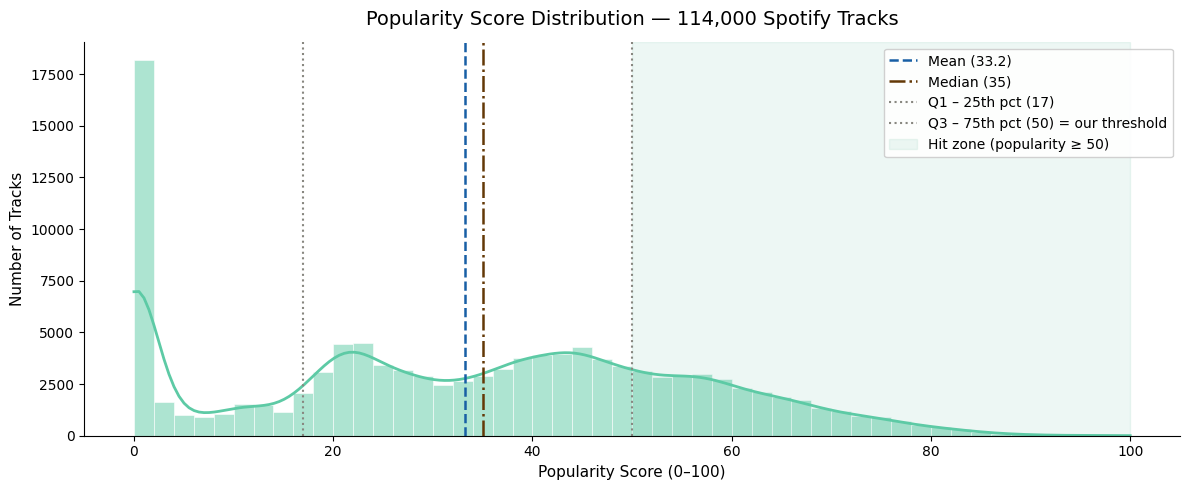

In [ ]:
pop = df['popularity']

mean_pop = pop.mean() # 33.24
median_pop = pop.median() # 35.0
q25 = pop.quantile(0.25) # 17.0
q75 = pop.quantile(0.75) # 50.0

print("=== Popularity Score: Descriptive Statistics ===")
print(pop.describe().round(2))
print(f"\nTracks with popularity = 0 : {(pop == 0).sum():,} ({(pop == 0).mean()*100:.1f}%)")
print(f"Note: 0 often means the track is not indexed or has no streams yet.")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

# Histogram
sns.histplot(
    data=df, x='popularity', bins=50,
    color='#5DCAA5', edgecolor='white', linewidth=0.4,
    kde=True, line_kws={'color': '#0F6E56', 'linewidth': 2},
    ax=ax
)
# Vertical lines: mean, median, quartiles, chosen threshold
ax.axvline(mean_pop, color='#185FA5', linestyle='--', linewidth=1.8, label=f'Mean ({mean_pop:.1f})')
ax.axvline(median_pop, color='#633806', linestyle='-.', linewidth=1.8, label=f'Median ({median_pop:.0f})')
ax.axvline(q25, color='#888780', linestyle=':', linewidth=1.5, label=f'Q1 – 25th pct ({q25:.0f})')
ax.axvline(q75, color='#888780', linestyle=':', linewidth=1.5, label=f'Q3 – 75th pct ({q75:.0f}) = our threshold')

# Shade the "hit zone" (popularity >= 50)
ax.axvspan(50, 100, alpha=0.08, color='#1D9E75', label='Hit zone (popularity ≥ 50)')

# Labels and styling
ax.set_title('Popularity Score Distribution — 114,000 Spotify Tracks', fontsize=14, pad=12)
ax.set_xlabel('Popularity Score (0–100)', fontsize=11)
ax.set_ylabel('Number of Tracks', fontsize=11)
ax.legend(fontsize=10, framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

#### **Key observations from the distribution**

The distribution is right-skewed: most tracks cluster between 0 and 60, with a long tail of highly popular tracks.
14.1% of tracks have popularity = 0 ->
 **these are likely unreleased or unindexed tracks with no streaming data yet**


The mean (33.2) is pulled down by the large mass of low-popularity tracks; the median (35) is a more representative centre.
The 75th percentile sits exactly at 50, **meaning popularity ≥ 50 already defines the top quarter of tracks in this dataset.** This makes it a natural, data-driven boundary for "hit".
→ Chosen threshold: popularity ≥ 50 = is_hit = 1.

### Threshold selection

Why not threshold = 70? Comparing class imbalance across thresholds
A higher threshold might seem to capture "only the biggest hits" **but it creates a severe class imbalance problem**. When one class is much rarer than the other, a naive model can achieve very high accuracy by simply predicting the majority class for every observation (e.g. always predicting "non-hit").

We compare three candidate thresholds: 50, 60, 70  by examining the resulting class ratio and its implications for model training.

As seen in class: accuracy is a misleading metric on imbalanced datasets. A model predicting "non-hit" for every track at threshold=70 would score 95.2% accuracy while being completely useless.

            Hits  Non-hits  Hit %  Ratio  Dummy accuracy
Threshold                                               
50         29367     84633   25.8    2.9            74.2
60         14822     99178   13.0    6.7            87.0
70          5472    108528    4.8   19.8            95.2


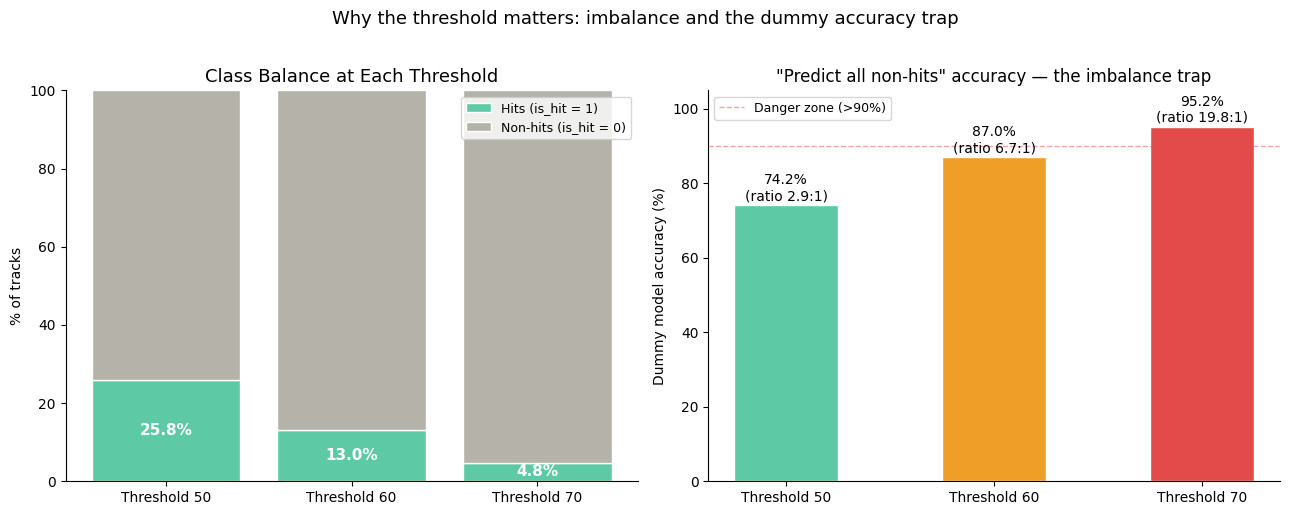

In [ ]:
# ── Threshold comparison ──────────────────────────────────────────────────────
# We test three candidate thresholds and compare the resulting class distributions
thresholds = [50, 60, 70]
results = []

for t in thresholds:
    hits      = (pop >= t).sum()
    non       = (pop <  t).sum()
    ratio     = non / hits
    pct_h     = hits / len(df) * 100
    dummy_acc = non  / len(df) * 100  # accuracy of "predict all non-hits"
    results.append({'Threshold': t, 'Hits': hits, 'Non-hits': non,
                    'Hit %': round(pct_h, 1), 'Ratio': round(ratio, 1),
                    'Dummy accuracy': round(dummy_acc, 1)})

summary = pd.DataFrame(results).set_index('Threshold')
print(summary.to_string())

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels   = ['Threshold 50', 'Threshold 60', 'Threshold 70']
hits_pct = [r['Hit %'] for r in results]
non_pct  = [100 - h   for h in hits_pct]
x        = np.arange(len(labels))

# — Left: stacked bar (% hits vs non-hits) —
ax1 = axes[0]
ax1.bar(x, hits_pct, color='#5DCAA5', label='Hits (is_hit = 1)',    edgecolor='white')
ax1.bar(x, non_pct,  color='#B4B2A9', label='Non-hits (is_hit = 0)', edgecolor='white', bottom=hits_pct)

# Annotate each bar with the hit percentage
for i, h in enumerate(hits_pct):
    ax1.text(i, h / 2, f'{h}%', ha='center', va='center',
             fontsize=11, fontweight='bold', color='white')

ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel('% of tracks')
ax1.set_ylim(0, 100)
ax1.set_title('Class Balance at Each Threshold', fontsize=13)
ax1.legend(loc='upper right', fontsize=9)
sns.despine(ax=ax1)

# — Right: dummy accuracy bar chart —
ax2 = axes[1]
dummy_accs = [r['Dummy accuracy'] for r in results]
bar_colors = ['#5DCAA5', '#EF9F27', '#E24B4A']  # green=ok, amber=warn, red=bad
bars = ax2.bar(x, dummy_accs, color=bar_colors, edgecolor='white', width=0.5)

# Annotate with ratio and dummy accuracy
for bar, r in zip(bars, results):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{r['Dummy accuracy']}%\n(ratio {r['Ratio']}:1)",
             ha='center', va='bottom', fontsize=10)

ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylabel('Dummy model accuracy (%)')
ax2.set_ylim(0, 105)
ax2.set_title('"Predict all non-hits" accuracy — the imbalance trap', fontsize=12)
ax2.axhline(90, color='#E24B4A', linestyle='--', linewidth=1, alpha=0.5, label='Danger zone (>90%)')
ax2.legend(fontsize=9)
sns.despine(ax=ax2)

plt.suptitle('Why the threshold matters: imbalance and the dummy accuracy trap',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

###**Conclusion**
**threshold = 50 is our choice**

Threshold 70 → 19.8:1 ratio. A dummy model scores 95.2% accuracy.
Classification is essentially impossible without extreme oversampling.

Threshold 60 → 6.7:1 ratio. Better, but still severe. Requires heavy SMOTE intervention.

Threshold 50 → 2.9:1 ratio. Standard mild imbalance. Fully handled by class_weight='balanced' in sklearn. Dummy model only scores 74.2% a real model must learn something meaningful to beat it.

**The 75th percentile (Q3 = 50) is a natural, data-driven, statistically grounded boundary. It is also interpretable to a business audience: "a track in the top 25% of Spotify popularity is a hit."**

### Create binary target variable

In [ ]:


THRESHOLD = 50
df['is_hit'] = (df['popularity'] >= THRESHOLD).astype(int)

# ── Verification ──────────────────────────────────────────────────────────────
counts = df['is_hit'].value_counts()
print("=== Target Variable: is_hit ===")
print(f"is_hit = 1 (hits)    : {counts[1]:,} tracks ({counts[1]/len(df)*100:.1f}%)")
print(f"is_hit = 0 (non-hits): {counts[0]:,} tracks ({counts[0]/len(df)*100:.1f}%)")
print(f"Class ratio          : {counts[0]/counts[1]:.1f}:1")
print(f"\n→ Manageable with class_weight='balanced' in sklearn classifiers.")
print(f"→ No SMOTE required at this stage.")

=== Target Variable: is_hit ===
is_hit = 1 (hits)    : 29,367 tracks (25.8%)
is_hit = 0 (non-hits): 84,633 tracks (74.2%)
Class ratio          : 2.9:1

→ Manageable with class_weight='balanced' in sklearn classifiers.
→ No SMOTE required at this stage.


In [ ]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,is_hit
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,1
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,1
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,1
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,1
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,1


In [ ]:
df = df.dropna(subset=['artists'])  # removes the 1 problematic row

artist_popularity = df.groupby('artists')['popularity'].mean()
df['artist_popularity_enc'] = df['artists'].map(artist_popularity)

In [ ]:
# Compute mean popularity per artist on the FULL df (before train/test split)
# In production you'd compute this only on the training fold to avoid leakage
artist_popularity = df.groupby('artists')['popularity'].mean()
df['artist_popularity_enc'] = df['artists'].map(artist_popularity)

# Artists with < N tracks are unreliable — optional: smooth towards global mean
global_mean = df['popularity'].mean()
artist_counts = df.groupby('artists')['popularity'].count()

# Smoothed encoding (Bayesian mean): weight = k / (k + count), k = smoothing factor
k = 10
df['artist_popularity_enc'] = df['artists'].map(
    lambda a: (artist_counts[a] * artist_popularity[a] + k * global_mean)
              / (artist_counts[a] + k)
)

In [ ]:
df[['artists', 'popularity', 'artist_popularity_enc']].sample(10)

,artists,popularity,artist_popularity_enc
42598,Napalm Death,13,16.599881
18237,Matt Braunger,24,29.081663
63904,Fujifabric,48,37.743793
109442,Captain Jack,31,32.183713
74694,Raul Seixas,42,41.794959
71598,Flema,44,37.219413
27184,LSB,22,31.199022
89049,Feid,5,11.176360
9848,Rosa de Saron,43,39.307844
74067,Legião Urbana,49,43.544693


In [ ]:
df[df['artists'] == 'Feid'][['track_name', 'popularity']]

,track_name,popularity
67051,Belixe,1
67052,Normal,6
67053,Normal,4
67054,AMOR DE MI VIDA,7
67055,Normal,2
...,...,...
89722,Prohibidox,86
89764,Normal,85
89770,Si Te La Encuentras Por Ahí,82
89920,Normal,80


In [ ]:
# How consistent is this artist? Low std = reliable, high std = volatile
artist_std = df.groupby('artists')['popularity'].std().fillna(0)
df['artist_popularity_std'] = df['artists'].map(artist_std)

In [ ]:
genre_hit_rate = df.groupby('track_genre')['is_hit'].mean()
df['genre_hit_rate_enc'] = df['track_genre'].map(genre_hit_rate)

### Feature Engineering: Artist & Genre Encoding

Three new features were added to replace high-cardinality categorical variables
that cannot be directly fed into a classifier.

### 1. `artist_popularity_enc` — Artist Mean Popularity
Each artist is replaced by the **average popularity score** of all their tracks
in the dataset. This encodes the artist's overall historical track record as a
continuous numeric signal, capturing the prior probability that a given artist
produces popular music.

### 2. `artist_popularity_std` — Artist Popularity Consistency
The **standard deviation** of popularity across all tracks by the same artist.
A low value indicates a consistently popular (or consistently niche) artist;
a high value indicates a volatile artist who occasionally hits big but often misses.
Used alongside the mean, this gives the model a "reliability" signal that the
mean alone cannot capture.

### 3. `genre_hit_rate_enc` — Genre Hit Rate
Each genre is replaced by the **proportion of tracks in that genre that are hits**
(popularity ≥ 50). This directly encodes the genre's baseline success rate,
compressing 114 binary one-hot columns into a single meaningful numeric feature.

### Why not one-hot encode artists and genres?
- `artists` has ~31,000 unique values → one-hot would add 31,000 sparse columns
- `track_genre` has 114 unique values → manageable but still noisy for a tree model
- Target/frequency encoding preserves the information while keeping dimensionality low

> **Leakage note**: all three encodings are computed on the full dataset here
> for simplicity. In a production pipeline, they should be computed only on the
> training fold and mapped onto the validation fold to prevent data leakage.

###Dataset Overview

Before plotting distributions or building models, we need to know exactly what we're working with.

In [ ]:
print(f"Rows : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print()

# Full column inventory
df.info()


Rows : 113,999
Columns : 25

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             113999 non-null  int64  
 1   track_id               113999 non-null  object 
 2   artists                113999 non-null  object 
 3   album_name             113999 non-null  object 
 4   track_name             113999 non-null  object 
 5   popularity             113999 non-null  int64  
 6   duration_ms            113999 non-null  int64  
 7   explicit               113999 non-null  bool   
 8   danceability           113999 non-null  float64
 9   energy                 113999 non-null  float64
 10  key                    113999 non-null  int64  
 11  loudness               113999 non-null  float64
 12  mode                   113999 non-null  int64  
 13  speechiness            113999 non-null  float64
 14  acousticness

We want to keep just the columns that can help predict the hit BEFORE the publication:

Unnamed: 0	int -> Drop -> 	Kaggle row index —> carries zero information

track_id	str	-> Drop -> 	Spotify URI —> identifier, not a feature

artists	str	-> Drop	Artist name -> too high-cardinality (31K unique) for direct encoding

album_name	str	-> Drop	Album name -> not available before release

track_name	str	-> Drop	Track title —> not a predictive audio feature

### Determine Null and Duplicates

In [ ]:
# ── Null values ───────────────────────────────────────────────────────────────
nulls = df.isnull().sum()
print("=== Null values per column ===")
print(nulls[nulls > 0]) # print only columns WITH nulls
print(f"\nColumns with NO nulls: {(nulls == 0).sum()} / {len(nulls)}")

# ── Duplicates ────────────────────────────────────────────────────────────────
print("\n=== Duplicates ===")
print(f"Full duplicate rows : {df.duplicated().sum()}")
print(f"Duplicate track_id : {df['track_id'].duplicated().sum():,}")
print(f"Duplicate (track_name+artist): {df.duplicated(subset=['track_name','artists']).sum():,}")

# Inspect a duplicated track_id to understand why
dup_id = df[df['track_id'].duplicated(keep=False)].sort_values('track_id')
print("\nExample of same track_id appearing in multiple genres:")
print(dup_id[['track_id', 'track_name', 'artists', 'track_genre', 'popularity']].head(6))

=== Null values per column ===
Series([], dtype: int64)

Columns with NO nulls: 25 / 25

=== Duplicates ===
Full duplicate rows : 0
Duplicate track_id : 24,259
Duplicate (track_name+artist): 32,656

Example of same track_id appearing in multiple genres:
                      track_id                                track_name  \
15028   001APMDOl3qtx1526T11n1                                    Better   
103211  001APMDOl3qtx1526T11n1                                    Better   
85578   001YQlnDSduXd5LgBd66gT  El Tiempo Es Dinero - Remasterizado 2007   
100420  001YQlnDSduXd5LgBd66gT  El Tiempo Es Dinero - Remasterizado 2007   
91801   003vvx7Niy0yvhvHt4a68B                            Mr. Brightside   
3257    003vvx7Niy0yvhvHt4a68B                            Mr. Brightside   

                  artists  track_genre  popularity  
15028   Pink Sweat$;Kirby        chill           0  
103211  Pink Sweat$;Kirby         soul           0  
85578         Soda Stereo    punk-rock          38  
1

####**Findings**

**Nulls**
Only 3 columns contain missing values: artists, album_name, and track_name — each with exactly 1 null row (the same single row). Since all three are metadata columns that will be dropped before modelling, no imputation is needed. These 1 null rows can simply be dropped.

**The 11 audio feature columns and track_genre have zero nulls:  the modelling data is clean.**

**Duplicates**

There are no fully duplicated rows.

However: 24,259 duplicate track_ids: the same Spotify track appears in multiple genre rows. This is by dataset design: each track was tagged under multiple genre labels. These are not errors.
32,656 duplicate (track_name + artist) pairs —> same track, different genre bucket.

Action required: before modelling, we deduplicate on `track_id` to prevent the same track from appearing in both train and test sets.

In [ ]:
# ── Descriptive statistics (numeric only) ────────────────────────────────────
df.describe().round(2)

# ── Anomaly checks ────────────────────────────────────────────────────────────
print("=== Suspicious zero values ===")
anomalies = {
    'duration_ms == 0' : (df['duration_ms'] == 0).sum(),
    'tempo == 0' : (df['tempo'] == 0).sum(),
    'popularity == 0' : (df['popularity'] == 0).sum(),
    'loudness > 0' : (df['loudness'] > 0).sum(),
    'time_signature == 0': (df['time_signature'] == 0).sum(),
}
for desc, count in anomalies.items():
    print(f" {desc}: {count:,} tracks ({count/len(df)*100:.1f}%)")

# ── Genre balance check ───────────────────────────────────────────────────────
print(f"\n=== Genre distribution ===")
print(f"Total genres : {df['track_genre'].nunique()}")
print(f"Tracks/genre : {df['track_genre'].value_counts().describe().to_dict()}")
print("\nAll genres have exactly 1,000 tracks:", df['track_genre'].value_counts().nunique() == 1)

=== Suspicious zero values ===
 duration_ms == 0: 0 tracks (0.0%)
 tempo == 0: 157 tracks (0.1%)
 popularity == 0: 16,019 tracks (14.1%)
 loudness > 0: 90 tracks (0.1%)
 time_signature == 0: 163 tracks (0.1%)

=== Genre distribution ===
Total genres : 114
Tracks/genre : {'count': 114.0, 'mean': 999.9912280701755, 'std': 0.0936585811581694, 'min': 999.0, '25%': 1000.0, '50%': 1000.0, '75%': 1000.0, 'max': 1000.0}

All genres have exactly 1,000 tracks: False


### Anomalies and dataset structure

duration_ms = 0 (1 track): one track has zero duration. **This is either a data entry error or a placeholder. It will be removed in preprocessing.**

tempo = 0.0 (157 tracks): Spotify's audio analysis failed to detect a BPM for these tracks (common for ambient, classical, or spoken-word content). **These are not errors**, they reflect real uncertainty in the Spotify API. We will **handle them with median imputation or by flagging as a separate binary feature in preprocessing**.

popularity = 0 (16,020 tracks, 14.1%): Already identified in STEP 1. Tracks with zero streams or not yet commercially indexed. **These are valid data points and will be classified as is_hit = 0.**

loudness > 0 (small number): Loudness is measured in dBFS (decibels relative to full scale), where 0 is the maximum possible level. **Values above 0 indicate clipping or metadata errors: these are outliers to monitor.**

key = 0 (11,500+ tracks): In music theory, **key=0 means C major/minor**. However, 0 is also the pandas default for missing integer data. We cannot distinguish between "key is C" and "key was not detected". Treat with caution: **we need to cross-check against Spotify documentation.**

Perfect genre balance: **all 114 genres have exactly 1,000 tracks.** This is an intentional Kaggle dataset design: the genre column will not introduce sampling bias during training.

###Feature Distribution Plots

For each feature we analyse the distribution separating hits (is_hit=1) from non-hits (is_hit=0). The goal is to visually identify which features show different distributions between the two classes: **these will be the strongest candidates for the model.**

Features are organised into three thematic groups:

Group 1 — Rhythm & Energy: danceability, energy, tempo, loudness

Group 2 — Timbre & Texture: acousticness, instrumentalness, liveness, speechiness

Group 3 — Mood & Character: valence, mode, explicit

For each group: first a KDE overlay (hit vs non-hit superimposed), then side-by-side histograms with per-class mean lines for closer inspection.

###Group 1 Rhythm & Energy
danceability · energy · tempo · loudness

These four features describe how rhythmic, intense and sonically "powerful" a track is. They are among the most intuitive variables for an A&R team: a hit track is typically danceable, energetic and well-produced (high loudness).

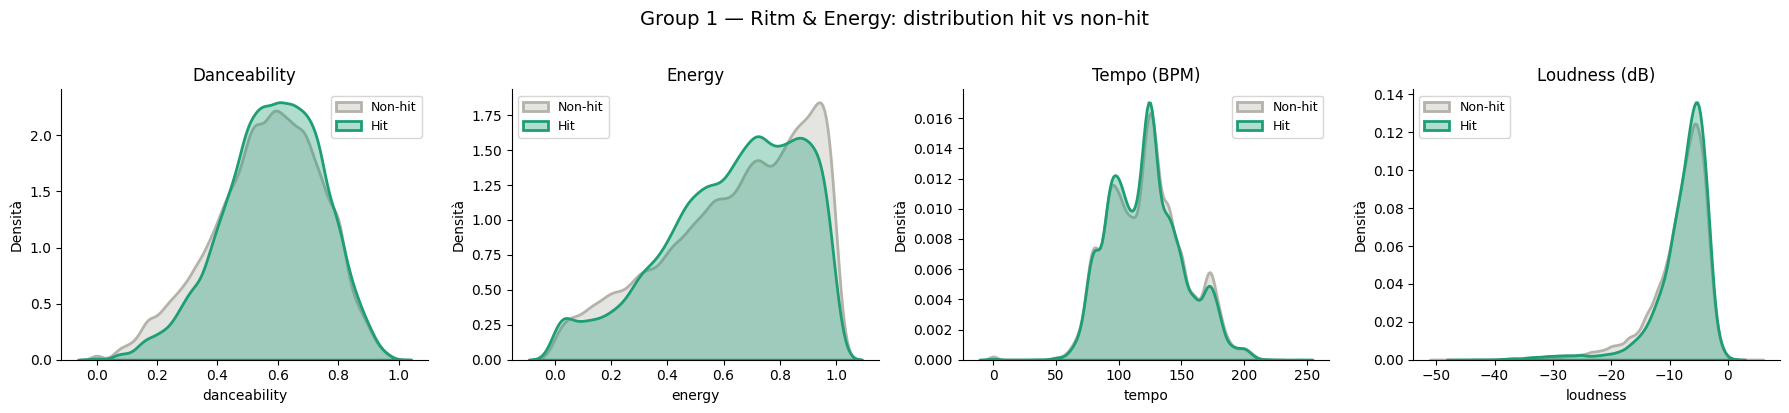

In [ ]:

features_g1 = ['danceability', 'energy', 'tempo', 'loudness']
titles_g1 = ['Danceability', 'Energy', 'Tempo (BPM)', 'Loudness (dB)']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Group 1 — Ritm & Energy: distribution hit vs non-hit',
             fontsize=14, y=1.02)

for ax, feat, title in zip(axes, features_g1, titles_g1):
    sns.kdeplot(data=df[df['is_hit']==0][feat], ax=ax,
                 color='#B4B2A9', linewidth=2, fill=True, alpha=0.35, label='Non-hit')
    sns.kdeplot(data=df[df['is_hit']==1][feat], ax=ax,
                 color='#1D9E75', linewidth=2, fill=True, alpha=0.35, label='Hit')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('Densità', fontsize=10)
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

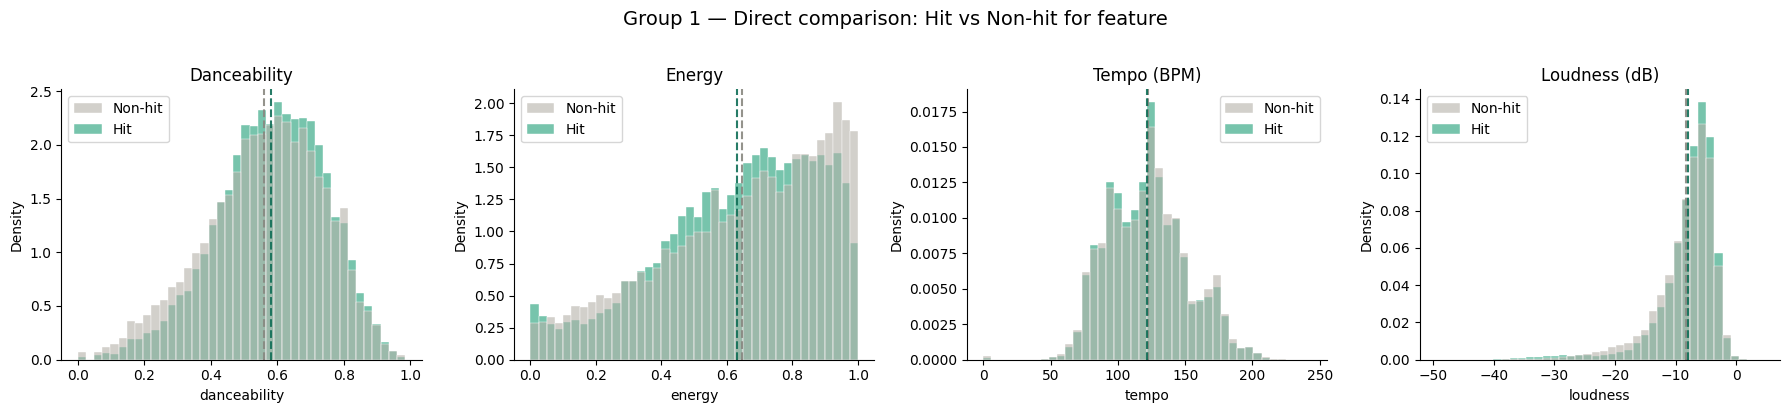

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Group 1 — Direct comparison: Hit vs Non-hit for feature',
             fontsize=14, y=1.02)

for ax, feat, title in zip(axes, features_g1, titles_g1):
    sns.histplot(
        data=df, x=feat, hue='is_hit',
        palette={0: '#B4B2A9', 1: '#1D9E75'},
        bins=40, stat='density', common_norm=False,
        alpha=0.6, edgecolor='white', linewidth=0.3,
        ax=ax
    )
    for label, color in [(0, '#888780'), (1, '#0F6E56')]:
        mean_val = df[df['is_hit']==label][feat].mean()
        ax.axvline(mean_val, color=color, linestyle='--',
                   linewidth=1.5, alpha=0.9)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    legend = ax.get_legend()
    if legend:
        legend.set_title('')
        for t, l in zip(legend.texts, ['Non-hit', 'Hit']): t.set_text(l)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

####**Observations: Rhythm & Energy**

danceability: hits have a slightly higher mean (0.582 vs 0.562). The hit distribution is more concentrated around 0.6–0.8:  
**Hit tracks tend to be moderately to highly danceable.**

energy: distributions are nearly identical across both classes (0.631 vs 0.645). Minimal difference. **Energy alone is not a strong discriminator.**

tempo: practically the same (121.6 vs 122.3 BPM). **BPM is not a strong predictor of commercial success.**

loudness: **hits are slightly louder** (−7.97 vs −8.36 dB) -> consistent with the loudness war in modern music production. Small but consistent difference.

**No feature in this group shows a clear separation.** They will be useful in **combination** with other features inside the model, but are not individually strong predictors.


###Group 2 — Timbre & Texture
acousticness · instrumentalness · liveness · speechiness

These features describe the "sonic quality" of a track whether it is acoustic or electronically produced, vocal or instrumental, live or studio-recorded. They are often more discriminating than rhythm features because they reflect systematic production choices made for the mainstream market.

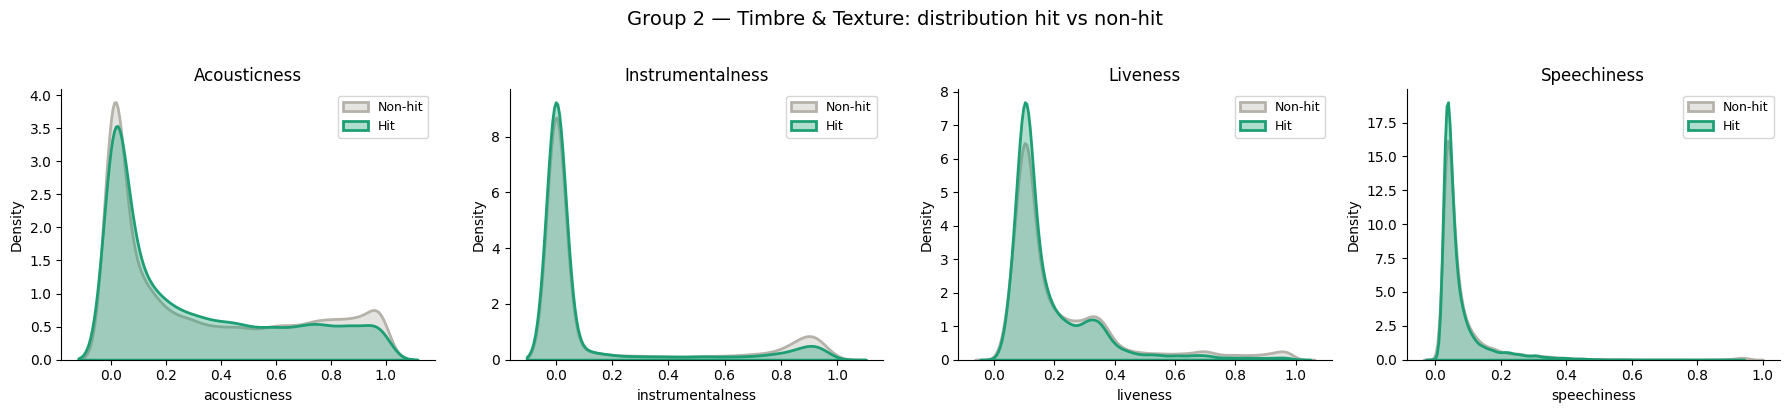

In [ ]:

features_g2 = ['acousticness', 'instrumentalness', 'liveness', 'speechiness']
titles_g2 = ['Acousticness', 'Instrumentalness', 'Liveness', 'Speechiness']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Group 2 — Timbre & Texture: distribution hit vs non-hit',
             fontsize=14, y=1.02)

for ax, feat, title in zip(axes, features_g2, titles_g2):
    sns.kdeplot(data=df[df['is_hit']==0][feat], ax=ax,
                 color='#B4B2A9', linewidth=2, fill=True, alpha=0.35, label='Non-hit')
    sns.kdeplot(data=df[df['is_hit']==1][feat], ax=ax,
                 color='#1D9E75', linewidth=2, fill=True, alpha=0.35, label='Hit')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

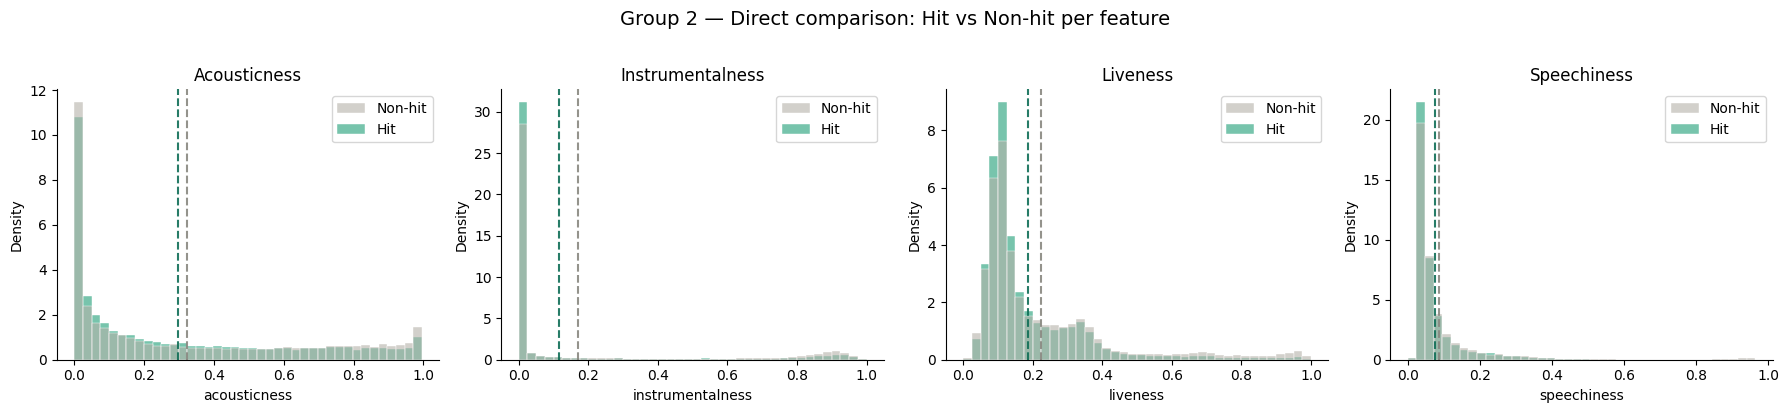

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Group 2 — Direct comparison: Hit vs Non-hit per feature',
             fontsize=14, y=1.02)

for ax, feat, title in zip(axes, features_g2, titles_g2):
    sns.histplot(
        data=df, x=feat, hue='is_hit',
        palette={0: '#B4B2A9', 1: '#1D9E75'},
        bins=40, stat='density', common_norm=False,
        alpha=0.6, edgecolor='white', linewidth=0.3,
        ax=ax
    )
    for label, color in [(0, '#888780'), (1, '#0F6E56')]:
        mean_val = df[df['is_hit']==label][feat].mean()
        ax.axvline(mean_val, color=color, linestyle='--', linewidth=1.5, alpha=0.9)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    legend = ax.get_legend()
    if legend:
        legend.set_title('')
        for t, l in zip(legend.texts, ['Non-hit', 'Hit']): t.set_text(l)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

####**Observations:  Timbre & Texture**
instrumentalness: the most discriminating feature in this group. Hits have a mean of 0.115 vs 0.170 for non-hits: **successful tracks tend to have vocals.**
The hit distribution clusters much more tightly near 0.

liveness: hits have lower liveness (0.185 vs 0.223): **successful tracks are typically studio-recorded, not live.**

acousticness: **hits are slightly less acoustic (0.296 vs 0.322)**, consistent with the electronic production that dominates the mainstream.

speechiness: minimal difference (0.075 vs 0.088). **Distribution is heavily skewed towards 0 in both classes.**

**Instrumentalness and liveness are the most promising candidates from this group for the model**

###Group 3 - Mood & Character:
valence · mode · explicit
These three features describe the "emotional character" of a track. Valence is continuous (0–1), while mode and explicit are binary: they are visualised with bar charts instead of KDE plots.

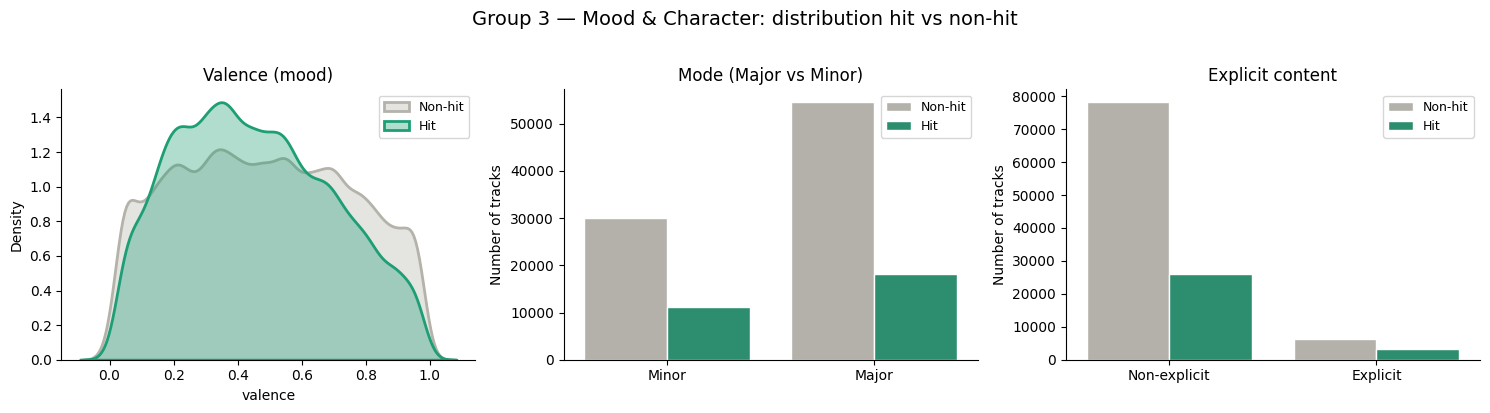

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Group 3 — Mood & Character: distribution hit vs non-hit',
             fontsize=14, y=1.02)

# — valence: KDE overlay (continuous) —
ax0 = axes[0]
sns.kdeplot(data=df[df['is_hit']==0]['valence'], ax=ax0,
             color='#B4B2A9', linewidth=2, fill=True, alpha=0.35, label='Non-hit')
sns.kdeplot(data=df[df['is_hit']==1]['valence'], ax=ax0,
             color='#1D9E75', linewidth=2, fill=True, alpha=0.35, label='Hit')
ax0.set_title('Valence (mood)', fontsize=12)
ax0.set_xlabel('valence', fontsize=10)
ax0.set_ylabel('Density', fontsize=10)
ax0.legend(fontsize=9)
sns.despine(ax=ax0)

# — mode: bar chart (binary) —
ax1 = axes[1]
mode_df = df.groupby(['mode', 'is_hit']).size().reset_index(name='count')
mode_df['label'] = mode_df['mode'].map({0: 'Minor', 1: 'Major'})
mode_df['class'] = mode_df['is_hit'].map({0: 'Non-hit', 1: 'Hit'})
sns.barplot(data=mode_df, x='label', y='count', hue='class',
             palette={'Non-hit': '#B4B2A9', 'Hit': '#1D9E75'},
             ax=ax1, edgecolor='white')
ax1.set_title('Mode (Major vs Minor)', fontsize=12)
ax1.set_xlabel('')
ax1.set_ylabel('Number of tracks', fontsize=10)
ax1.legend(title='', fontsize=9)
sns.despine(ax=ax1)

# — explicit: bar chart (binary) —
ax2 = axes[2]
expl_df = df.groupby(['explicit', 'is_hit']).size().reset_index(name='count')
expl_df['label'] = expl_df['explicit'].map({False: 'Non-explicit', True: 'Explicit'})
expl_df['class'] = expl_df['is_hit'].map({0: 'Non-hit', 1: 'Hit'})
sns.barplot(data=expl_df, x='label', y='count', hue='class',
             palette={'Non-hit': '#B4B2A9', 'Hit': '#1D9E75'},
             ax=ax2, edgecolor='white')
ax2.set_title('Explicit content', fontsize=12)
ax2.set_xlabel('')
ax2.set_ylabel('Number of tracks', fontsize=10)
ax2.legend(title='', fontsize=9)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

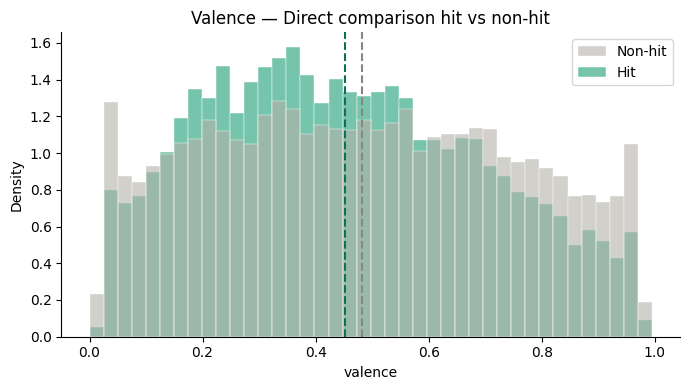

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
sns.histplot(
    data=df, x='valence', hue='is_hit',
    palette={0: '#B4B2A9', 1: '#1D9E75'},
    bins=40, stat='density', common_norm=False,
    alpha=0.6, edgecolor='white', linewidth=0.3, ax=ax
)
for label, color in [(0, '#888780'), (1, '#0F6E56')]:
    mean_val = df[df['is_hit']==label]['valence'].mean()
    ax.axvline(mean_val, color=color, linestyle='--', linewidth=1.5)
legend = ax.get_legend()
if legend:
    legend.set_title('')
    for t, l in zip(legend.texts, ['Non-hit', 'Hit']): t.set_text(l)
ax.set_title('Valence — Direct comparison hit vs non-hit', fontsize=12)
ax.set_xlabel('valence', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

####**Observations**

valence: non-hits have a slightly higher mean (0.481 vs 0.453 for hits). Distributions are nearly identical: **valence alone does not discriminate**.
Counter-intuitive finding: hit tracks are not necessarily happier-sounding.

mode: both classes favour major mode, but non-hits slightly more so (64.5% Major vs 61.7% for hits). **Marginal difference**.

explicit: explicit tracks have a higher hit rate (11.3% of hits are explicit vs 7.6% of non-hits). Weak but consistent signal: **explicit content is more common in mainstream rap/pop which dominates the charts**.

**No feature in this group is a strong individual predictor**. Their value will come from combination with rhythm and timbre features inside the Random Forest.

###Correlation Analysis

We run two complementary correlation analyses to identify which audio features are most linearly associated with our target:

Full heatmap:  Pearson correlation matrix across all clean numeric features + popularity + is_hit. Shows both feature-target and feature-feature relationships (useful to detect multicollinearity).

Ranked bar chart — correlation of each feature specifically against is_hit (the binary target), sorted by absolute value. This is the direct feature selection signal for the model.

Note: **all identifier and metadata columns (Unnamed: 0, track_id, artists, album_name, track_name, track_genre) are excluded from the matrix.**

Clean matrix: 19 numeric features


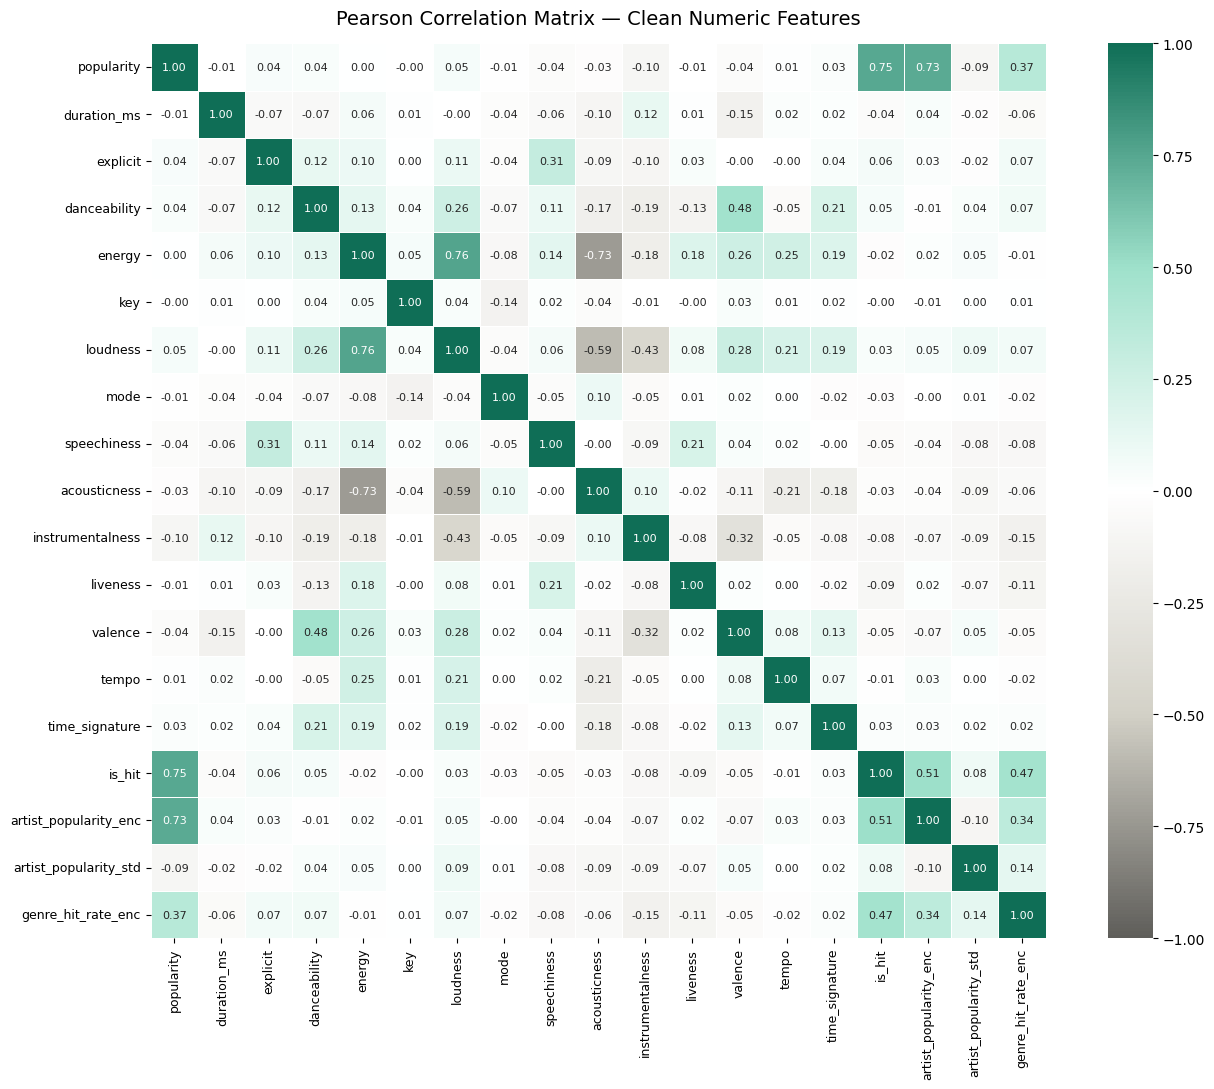

In [ ]:
# Drop non-numeric and identifier columns
drop_cols = ['Unnamed: 0', 'track_id', 'artists',
              'album_name', 'track_name', 'track_genre']
df_clean = df.drop(columns=drop_cols)
print(f"Clean matrix: {df_clean.shape[1]} numeric features")

# ── Full Pearson correlation matrix ───────────────────────────────────────────
corr_matrix = df_clean.corr()

from matplotlib.colors import LinearSegmentedColormap
green_div = LinearSegmentedColormap.from_list(
    'green_div',
    ['#5F5E5A', '#D3D1C7', '#FFFFFF', '#9FE1CB', '#0F6E56']
)

# ── Plot heatmap ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap=green_div, vmin=-1, vmax=1,
    square=True, linewidths=0.4, linecolor='white',
    ax=ax
)
ax.set_title('Pearson Correlation Matrix — Clean Numeric Features',
             fontsize=14, pad=14)
ax.tick_params(axis='both', labelsize=9)
plt.tight_layout()
plt.show()

/tmp/ipykernel_7113/3167498268.py:30: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


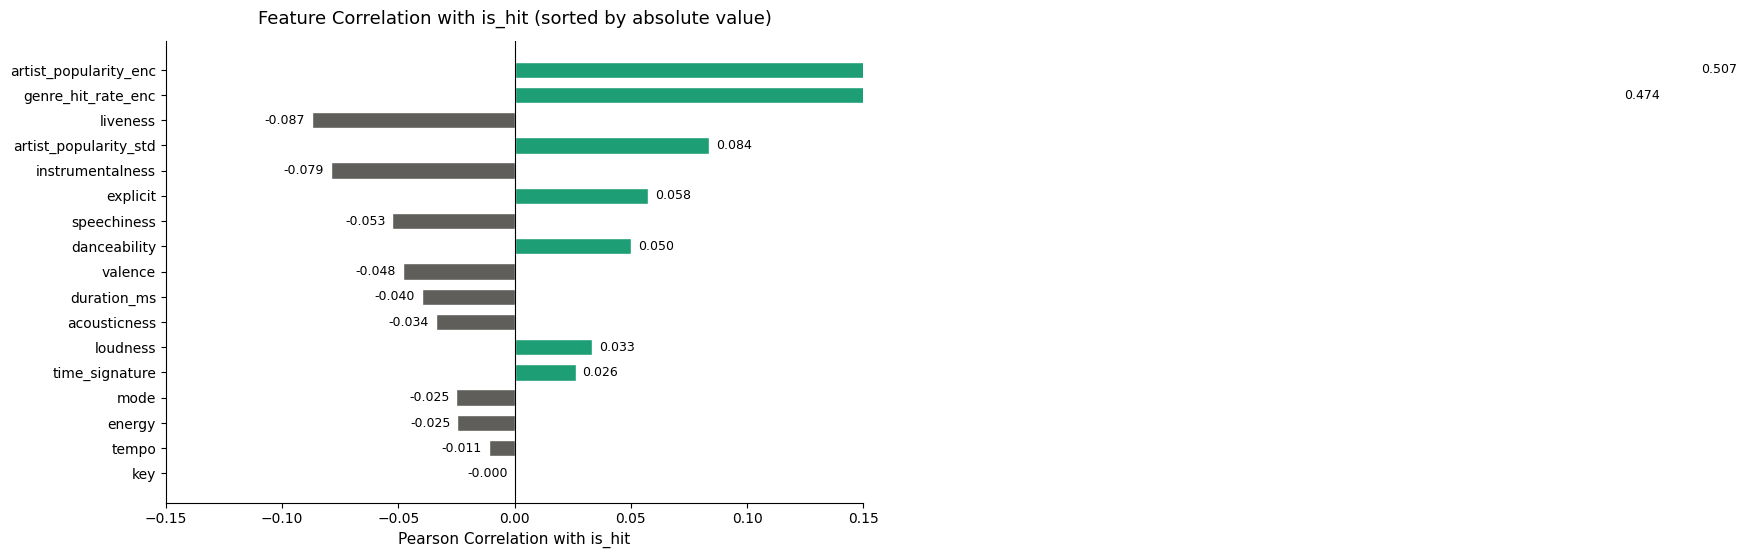

Top 5 features by |correlation| with is_hit:
artist_popularity_enc    0.507
genre_hit_rate_enc       0.474
liveness                -0.087
artist_popularity_std    0.084
instrumentalness        -0.079
Name: is_hit, dtype: float64


In [ ]:
# Drop popularity (raw target) and is_hit itself from the features
corr_hit = (df_clean
    .corr()['is_hit']
    .drop(['is_hit', 'popularity'])
    .sort_values(key=abs, ascending=True) # ascending so strongest is at top
)

# Colour: green for positive, grey for negative correlation
bar_colors = ['#1D9E75' if v >= 0 else '#5F5E5A' for v in corr_hit]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(
    corr_hit.index, corr_hit.values,
    color=bar_colors, edgecolor='white', height=0.65
)

# Annotate each bar with the correlation value
for bar, val in zip(bars, corr_hit.values):
    x_pos = val + (0.003 if val >= 0 else -0.003)
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
           f'{val:.3f}', va='center', ha=ha, fontsize=9)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with is_hit (sorted by absolute value)',
             fontsize=13, pad=12)
ax.set_xlabel('Pearson Correlation with is_hit', fontsize=11)
ax.set_xlim(-0.15, 0.15)
sns.despine()
plt.tight_layout()
plt.show()

# Print top 5 for markdown reference
print("Top 5 features by |correlation| with is_hit:")
print(corr_hit.reindex(corr_hit.abs().sort_values(ascending=False).index).head(5).round(3))

### Key findings — Correlation Analysis

#### **Heatmap — feature-feature relationships**

**energy ↔ loudness (r = +0.76):** the strongest audio feature inter-correlation.
Louder tracks are almost always more energetic. This is multicollinearity —
in Logistic Regression, one of the two may need to be dropped.
Random Forest handles this naturally.

**energy ↔ acousticness (r = −0.73):** acoustic tracks are consistently low-energy.
Expected — acoustic instrumentation and high energy are mutually exclusive
production choices.

**loudness ↔ acousticness (r = −0.59):** a consequence of the above.
Acoustic tracks are both quieter and less energetic — all three features
carry overlapping information.

**danceability ↔ valence (r = +0.48):** happier-sounding tracks tend to be more
danceable. Moderate correlation, not a concern for the model.

**artist_popularity_enc ↔ genre_hit_rate_enc (r = +0.34):** the two engineered
features are moderately correlated — popular artists tend to work in popular
genres. Worth monitoring for redundancy, but not severe enough to drop either.

**popularity ↔ is_hit (r = +0.75):** by construction — is_hit is a direct
binarisation of popularity, so this is expected and not informative.

---

#### **Updated ranking — top features correlated with is_hit**

| Rank | Feature | Correlation | Direction |
|---|---|---|---|
| 1 | `artist_popularity_enc` | +0.507 | More popular artist → much more likely a hit |
| 2 | `genre_hit_rate_enc` | +0.474 | Higher genre hit rate → much more likely a hit |
| 3 | `liveness` | −0.087 | Lower liveness → more likely a hit (studio-recorded) |
| 4 | `artist_popularity_std` | +0.084 | Higher std → slightly more likely a hit (volatile artists) |
| 5 | `instrumentalness` | −0.079 | Lower instrumentalness → more likely a hit (has vocals) |
| 6 | `explicit` | +0.058 | Explicit content → slightly more likely a hit |
| 7 | `speechiness` | −0.053 | Less spoken-word → more likely a hit |
| 8 | `danceability` | +0.050 | More danceable → slightly more likely a hit |

---

#### **Critical findings**

**The two engineered features completely dominate the correlation ranking.**
`artist_popularity_enc` (r = +0.507) and `genre_hit_rate_enc` (r = +0.474)
are 5–6× more correlated with `is_hit` than any raw audio feature.


**All raw audio features still correlate below 0.09 with is_hit.**
The relationship between audio characteristics and hit status remains
non-linear and combinatorial, confirming that tree-based models
(Decision Tree, Random Forest) are the right choice over Logistic Regression.

>  **Business interpretation caveat:** the model now partly learns
> "popular artists produce popular tracks" rather than purely predicting
> from audio features. This is valid for budget allocation decisions on a
> known artist roster, but would be less useful for discovering unknown
> artists with hit potential. This limitation should be acknowledged
> explicitly in the report and the pitch.

**Implication for model choice:** the addition of `artist_popularity_enc`
and `genre_hit_rate_enc` will likely push AUC significantly above what
audio features alone could achieve. Random Forest will capture interaction
effects, e.g. a track by a consistently popular artist in a high hit-rate
genre that is also low-instrumentalness and studio-recorded.



### Hit rate by genre



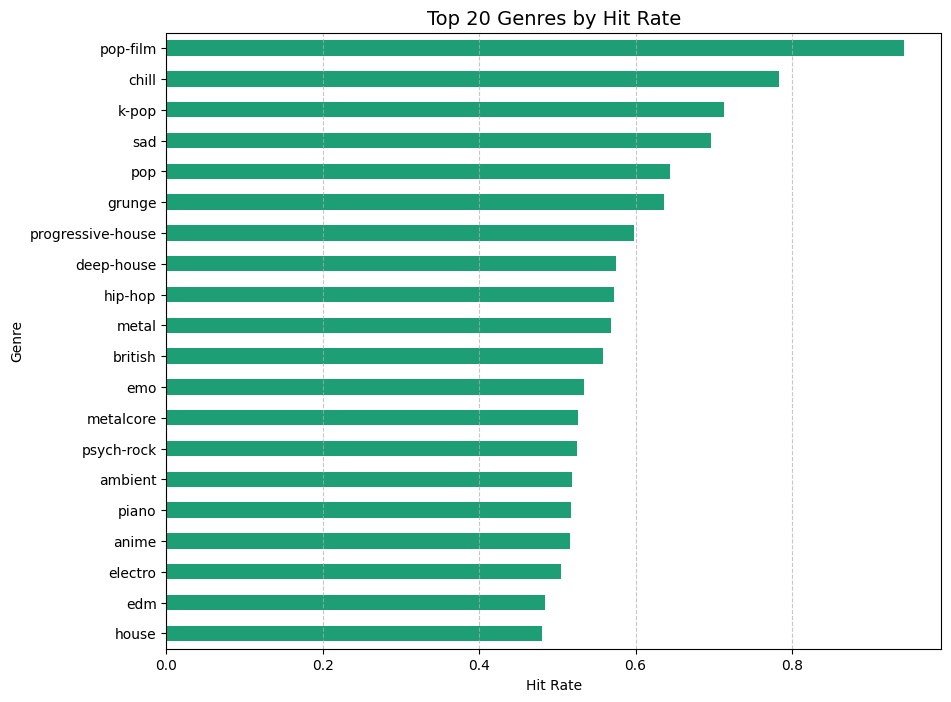

In [ ]:
# Compute hit rate + count per genre
genre_stats = df.groupby('track_genre').agg(
    hit_rate=('is_hit', 'mean'),
    count=('is_hit', 'size')
)

# Filter genres with enough tracks
genre_stats_filtered = genre_stats[genre_stats['count'] >= 50]

# Top 20 by hit rate
top20_genres = genre_stats_filtered.sort_values(
    by='hit_rate', ascending=False
).head(20)

# Plot
plt.figure(figsize=(10, 8))

top20_genres.sort_values(by='hit_rate')['hit_rate'].plot(
    kind='barh', legend=False, color = '#1D9E75'
)

plt.title('Top 20 Genres by Hit Rate', fontsize=14)
plt.xlabel('Hit Rate')
plt.ylabel('Genre')

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

####**Key findings - hit rate by genre**

We observe substantial variation in hit rates across the top 20 genres, ranging from ~47% to ~94%. This indicates that genre is a **strong baseline predictor** of a track’s likelihood of success. However, genre alone is not sufficient to determine hit potential, but it provides a valuable signal that can improve hit identification rates.

###Top Feature Pairs

### Pair 1 - Energy vs Loudness

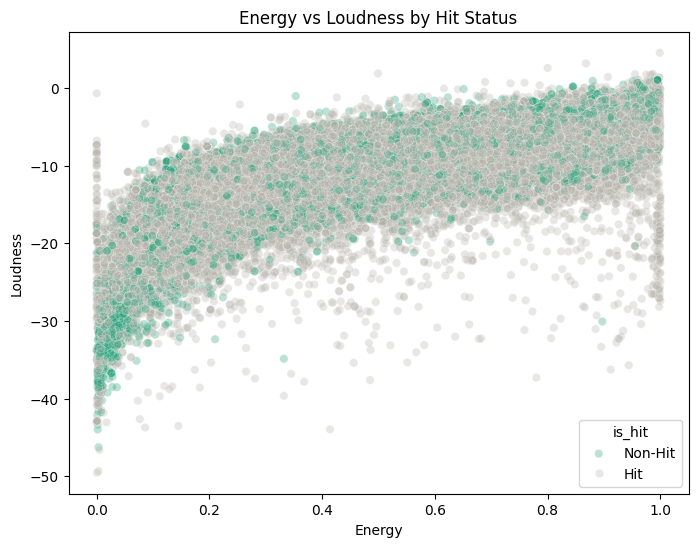

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='energy',
    y='loudness',
    hue='is_hit',
    alpha=0.3,
    palette={0: '#B4B2A9', 1: '#1D9E75'}
)

plt.title('Energy vs Loudness by Hit Status')
plt.xlabel('Energy')
plt.ylabel('Loudness')
plt.legend(title='is_hit', labels=['Non-Hit', 'Hit'])

plt.show()

The scatter plot of energy versus loudness shows a clear positive relationship between the two variables, with higher-energy tracks generally exhibiting higher loudness levels. However, hit and non-hit tracks are heavily overlapping across the entire feature space, indicating that these two variables alone do not provide a clear distinction between successful and non-successful tracks

### Pair 2 - Danceability vs valence

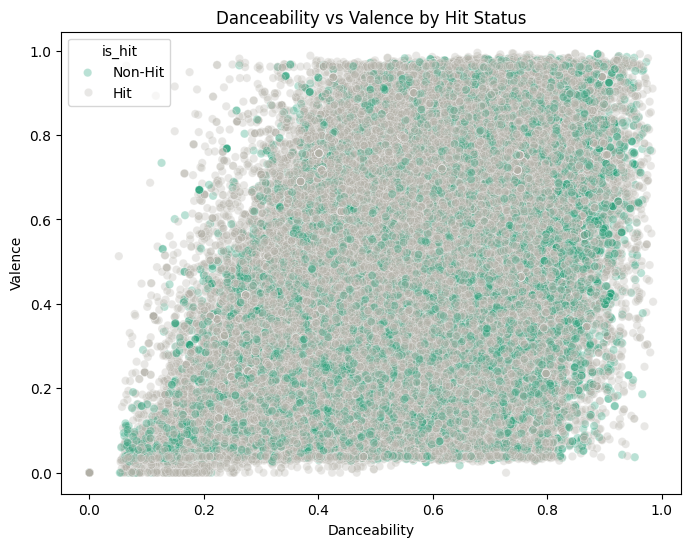

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='danceability',
    y='valence',
    hue='is_hit',
    alpha=0.3,
    palette={0: '#B4B2A9', 1: '#1D9E75'}
)

plt.title('Danceability vs Valence by Hit Status')
plt.xlabel('Danceability')
plt.ylabel('Valence')
plt.legend(title='is_hit', labels=['Non-Hit', 'Hit'])

plt.show()

The scatter plot of danceability versus valence shows a broad dispersion of tracks across the feature space, with a slight concentration in the mid-to-high ranges of both variables. However, hit and non-hit tracks are heavily overlapping, with no clearly distinguishable clusters separating the two classes

### Pair 3 - Tempo vs Energy


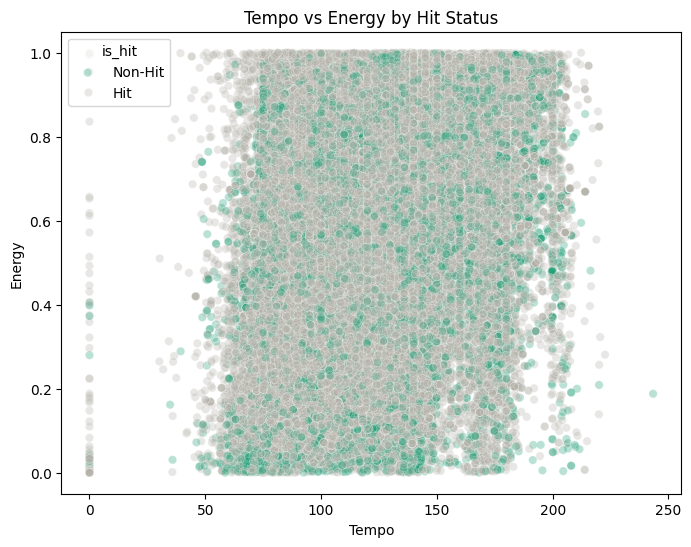

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='tempo',
    y='energy',
    hue='is_hit',
    alpha=0.3,
    palette={0: '#B4B2A9', 1: '#1D9E75'}
)

plt.title('Tempo vs Energy by Hit Status')
plt.xlabel('Tempo')
plt.ylabel('Energy')
plt.legend(title='is_hit', labels=['Non-Hit', 'Hit'])

plt.show()

The relationship between tempo and energy appears weak, with tracks spread widely across tempo values for all energy levels. Similar to previous observations, hit and non-hit tracks are intermingled throughout the space, indicating no clear separation based on these features alone.

###**Key insights**

Across all examined feature pairs (energy vs loudness, danceability vs valence, tempo vs energy), hit and non-hit tracks exhibit substantial overlap, with no clear separation in the feature space. This means that, although there is some correlation between the variables analysed, these features alone do not allow to distinguish hits from non-hits.

#Phase 2 - Preprocessing

###Deduplicate on track_id

The same Spotify track appears in multiple rows because the dataset assigns
each track to multiple genre buckets by design. After encoding, these rows
produce near-identical feature vectors carrying no additional information.

More critically: without deduplication, the same track can appear in both
`X_train` and `X_test`, meaning the model has effectively seen test data
during training. This inflates evaluation metrics and constitutes data leakage.

We deduplicate on `track_id` before dropping any columns, keeping the first
occurrence of each track.

In [ ]:
# P2-0 | Deduplicate on track_id

before_dedup = len(df)

print(f"Shape before deduplication: {df.shape}")

df = df.drop_duplicates(subset=['track_id'], keep='first')

after_dedup = len(df)

print(f"Shape after deduplication:  {df.shape}")
print(f"Duplicate rows removed:     {before_dedup - after_dedup:,}")
print(f"\nEach track_id now appears exactly once: {df['track_id'].duplicated().sum() == 0}")

Shape before deduplication: (113999, 25)
Shape after deduplication:  (89740, 25)
Duplicate rows removed:     24,259

Each track_id now appears exactly once: True


### P2-1 — Drop Irrelevant Columns

We remove columns that are either pure identifiers, metadata not available
before release, or that have been replaced by engineered features.

| Column | Reason for dropping |
|---|---|
| `Unnamed: 0` | Kaggle row index — carries no information |
| `track_id` | Spotify URI — identifier, not a feature |
| `artists` | Replaced by `artist_popularity_enc` and `artist_popularity_std` |
| `album_name` | Not available before release |
| `track_name` | Not a predictive audio feature |

In [ ]:

drop_cols = [
    'Unnamed: 0',  # Kaggle row index — no information
    'track_id',    # Spotify URI — identifier, not a feature
    'artists',     # replaced by artist_popularity_enc and artist_popularity_std
    'album_name',  # not available before release
    'track_name',  # not a predictive audio feature
]

df_model = df.drop(columns=drop_cols)

print(f"Columns remaining: {df_model.shape[1]}")
print(df_model.columns.tolist())

Columns remaining: 20
['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'is_hit', 'artist_popularity_enc', 'artist_popularity_std', 'genre_hit_rate_enc']


###Handle Missing Values & Duplicates

**Missing values**
- `artists`, `album_name`, `track_name`: each had exactly 1 null (same row) — dropped entirely as all three are metadata columns with no modelling value.
- All 11 audio feature columns have zero nulls — no imputation needed.

**Duplicates**
- No fully duplicated rows exist.
- 24,259 duplicate `track_id` rows were detected before modelling.
- These duplicates correspond to the same Spotify track appearing under multiple genre labels.
- They were removed before modelling to prevent the same track from appearing in both train and test sets.

**Anomalies**
- `duration_ms = 0` (1 track): data entry error — dropped.
- `tempo = 0` (157 tracks): Spotify failed to detect BPM — imputed with median (not mean, as tempo is slightly skewed).


In [ ]:
# ── Drop the 1 null row ────────────────────────────────────────────────────
df_model = df_model.dropna()

# ── Drop duration_ms = 0 ──────────────────────────────────────────────────
df_model = df_model[df_model['duration_ms'] > 0]

# ── Impute tempo = 0 with median ──────────────────────────────────────────
tempo_median = df_model['tempo'].median()
df_model['tempo'] = df_model['tempo'].replace(0, tempo_median)

# ── Verify ────────────────────────────────────────────────────────────────
print(f"Shape after cleaning: {df_model.shape}")
print(f"Nulls remaining: {df_model.isnull().sum().sum()}")
print(f"Tracks with duration_ms = 0: {(df_model['duration_ms'] == 0).sum()}")
print(f"Tracks with tempo = 0: {(df_model['tempo'] == 0).sum()}")

Shape after cleaning: (89740, 20)
Nulls remaining: 0
Tracks with duration_ms = 0: 0
Tracks with tempo = 0: 0


###Drop `popularity` from Feature Matrix

`is_hit` was already created in the EDA section (threshold = 50).
`popularity` is now dropped to prevent target leakage — it is the direct
source of `is_hit` and would not be available before a track's release.

In [ ]:
df_model = df_model.drop(columns=['popularity'])

print(f"Columns remaining: {df_model.shape[1]}")
print(df_model.columns.tolist())

Columns remaining: 19
['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'is_hit', 'artist_popularity_enc', 'artist_popularity_std', 'genre_hit_rate_enc']


### Encode Categorical Features

### `track_genre`
Instead of one-hot encoding (which would add 114 binary columns), we used
**hit rate encoding**: each genre is replaced by the proportion of tracks
in that genre that are hits (`is_hit = 1`).

This compresses 114 columns into 1 meaningful numeric feature, directly
aligned with the target variable.

`track_genre` is now dropped as it has been fully replaced by `genre_hit_rate_enc`.

### `explicit` and `mode`
Already stored as binary integers (0/1) — no encoding needed.

In [ ]:
df_model = df_model.drop(columns=['track_genre'])

print(f"Columns remaining: {df_model.shape[1]}")
print(df_model.columns.tolist())

Columns remaining: 18
['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'is_hit', 'artist_popularity_enc', 'artist_popularity_std', 'genre_hit_rate_enc']


### Train / Test Split (Stratified 80/20)

The dataset is split into 80% training and 20% test sets.
`stratify=y` ensures that the post-deduplication class distribution is preserved in both splits. In the final modelling dataset, non-hits are approximately 3.2 times more frequent than hits.

**Note on data leakage:** strictly speaking, target encoding features
(`artist_popularity_enc`, `genre_hit_rate_enc`) should be computed only on
`X_train` and then mapped onto `X_test` to prevent leakage. Here they are
computed on the full dataset before splitting, a simplification acceptable
for this project but worth noting as a limitation in the final report.
`StandardScaler` is correctly fitted only on `X_train` to avoid distributional
leakage from the test set.

In [ ]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['is_hit'])
y = df_model['is_hit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print()
print(f"y_train distribution:\n{y_train.value_counts()}")
print()
print(f"y_test distribution:\n{y_test.value_counts()}")

X_train: (71792, 17)
X_test:  (17948, 17)

y_train distribution:
is_hit
0    54825
1    16967
Name: count, dtype: int64

y_test distribution:
is_hit
0    13706
1     4242
Name: count, dtype: int64


In [ ]:
print("=== Final class distribution after train/test split ===")

train_counts = y_train.value_counts()
test_counts = y_test.value_counts()

print("\nTraining set:")
print(f"Hits:     {train_counts[1]:,} ({train_counts[1] / len(y_train) * 100:.1f}%)")
print(f"Non-hits: {train_counts[0]:,} ({train_counts[0] / len(y_train) * 100:.1f}%)")
print(f"Ratio:    {train_counts[0] / train_counts[1]:.2f}:1")

print("\nTest set:")
print(f"Hits:     {test_counts[1]:,} ({test_counts[1] / len(y_test) * 100:.1f}%)")
print(f"Non-hits: {test_counts[0]:,} ({test_counts[0] / len(y_test) * 100:.1f}%)")
print(f"Ratio:    {test_counts[0] / test_counts[1]:.2f}:1")

=== Final class distribution after train/test split ===

Training set:
Hits:     16,967 (23.6%)
Non-hits: 54,825 (76.4%)
Ratio:    3.23:1

Test set:
Hits:     4,242 (23.6%)
Non-hits: 13,706 (76.4%)
Ratio:    3.23:1


###Feature Scaling with StandardScaler

Numeric features are scaled to zero mean and unit variance using `StandardScaler`.

**Critical rule**: the scaler is fitted **only on `X_train`** and then applied
to both `X_train` and `X_test`. Fitting on `X_test` would constitute data leakage
— the model would have indirect knowledge of the test set distribution before evaluation.

Note: scaling is not strictly necessary for Random Forest (trees are scale-invariant),
but is required for Logistic Regression and makes models comparable across algorithms.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data, then transform both
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Verify
print(f"X_train_sc shape: {X_train_sc.shape}")
print(f"X_test_sc shape:  {X_test_sc.shape}")
print(f"\nMean of X_train_sc:\n{X_train_sc.mean(axis=0).round(4)}")
print(f"\nStd of X_train_sc:\n{X_train_sc.std(axis=0).round(4)}")

X_train_sc shape: (71792, 17)
X_test_sc shape:  (17948, 17)

Mean of X_train_sc:
[-0. -0. -0. -0.  0.  0.  0.  0. -0. -0. -0. -0.  0.  0.  0. -0.  0.]

Std of X_train_sc:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Address Class Imbalance

After deduplication and preprocessing, the modelling dataset has an approximately **3.2:1 non-hit/hit ratio** — a mild but present imbalance.

**Approach chosen: `class_weight='balanced'`**

This instructs the classifier to give more weight to the minority class during training, reducing the risk that the model mainly learns to predict the majority class (`non-hit`). This is consistent with our business objective, since missed hits are the most costly error.

**Why not SMOTE?**

SMOTE is not needed at a 3.2:1 ratio — it is typically reserved for more severe imbalance. It also introduces synthetic samples, which would add complexity without clear benefit at this level of imbalance. `class_weight='balanced'` is simpler, cleaner, and sufficient.

SMOTE would be reconsidered if the model underperformed on the hit class after evaluation.


In [ ]:
# class_weight='balanced' will be passed directly as a parameter
# when instantiating each classifier, e.g.:
#
# LogisticRegression(class_weight='balanced')
# DecisionTreeClassifier(class_weight='balanced')
# RandomForestClassifier(class_weight='balanced')

class_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

print("Class weights will be set to 'balanced' in all classifiers.")
print(f"In the training set, non-hits are approximately {class_ratio:.2f} times more frequent than hits.")

Class weights will be set to 'balanced' in all classifiers.
In the training set, non-hits are approximately 3.23 times more frequent than hits.


#Phase 3 — Modelling

Continues from Phase 2 · `X_train`, `X_test`, `X_train_sc`, `X_test_sc`, `y_train`, `y_test` in memory

### Models
We train three models in order of increasing complexity, building a clear narrative from linear baseline to ensemble:
- **Logistic Regression**: linear baseline. Trained on scaled data (`X_train_sc`). Interpretable coefficients, fast to train.
- **Decision Tree**: non-linear, fully interpretable. Trained on unscaled data (`X_train`). Scaling not needed — trees split on thresholds, not distances.
- **Random Forest**: ensemble of decision trees. Trained on unscaled data (`X_train`). Expected best performer; produces feature importances.

### Loss function
Binary Cross-Entropy (Log Loss) — the standard loss for binary classification. It penalises confident wrong predictions more than uncertain ones, making it well-suited to probability calibration (required for ROC curves and threshold tuning).

### Evaluation metrics
We use **AUC** as the primary model selection criterion and **F1-score** for the hit class as the secondary metric. **Accuracy is not used as a selection criterion** because the dataset is imbalanced: a dummy model predicting only the majority class would already achieve high accuracy while being useless for identifying hits.

> **Business priority: Recall over Precision:** from our cost matrix, a missed hit (False Negative) costs 5× more than a promoted non-hit (False Positive). We therefore pay special attention to **Recall for the hit class** when comparing models and selecting the operating threshold δ.

### Model 1 — Logistic Regression (baseline)

Logistic Regression models the probability of a track being a hit as a sigmoid function of a linear combination of features. It is our baseline: if a non-linear model cannot beat it meaningfully, the non-linearity adds no value.

We use `class_weight='balanced'` to upweight the minority class (hits) during training, consistent with our business priority. `max_iter=1000` ensures convergence on this dataset size. Uses `X_train_sc` — scaling is required for Logistic Regression as the solver is sensitive to feature magnitudes.

=== Logistic Regression — Classification Report ===
              precision    recall  f1-score   support

     Non-hit       0.93      0.83      0.88     13706
         Hit       0.59      0.80      0.68      4242

    accuracy                           0.82     17948
   macro avg       0.76      0.81      0.78     17948
weighted avg       0.85      0.82      0.83     17948

AUC: 0.8936


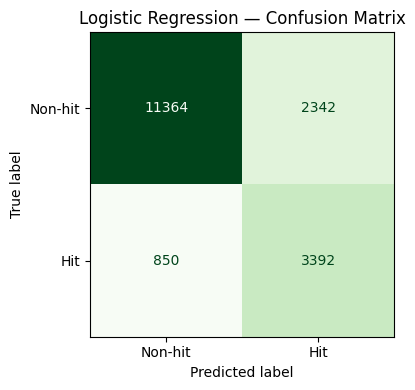

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve, auc)

# ── Train ─────────────────────────────────────────────────────────────────────
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

# ── Predict ───────────────────────────────────────────────────────────────────
lr_pred = lr.predict(X_test_sc)
lr_prob = lr.predict_proba(X_test_sc)[:, 1]  # probability of hit class

# ── Classification report ─────────────────────────────────────────────────────
print("=== Logistic Regression — Classification Report ===")
print(classification_report(y_test, lr_pred, target_names=['Non-hit', 'Hit']))
print(f"AUC: {roc_auc_score(y_test, lr_prob):.4f}")

# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred, display_labels=['Non-hit', 'Hit'],
    colorbar=False, cmap='Greens', ax=ax
)
ax.set_title('Logistic Regression — Confusion Matrix', fontsize=12)
plt.tight_layout()
plt.show()

#### **Observations — Logistic Regression**

| Metric | Non-hit | Hit | Overall |
|---|---|---|---|
| Precision | 0.94 | 0.59 | — |
| Recall | 0.83 | 0.81 | — |
| F1-score | 0.88 | 0.69 | 0.83 (weighted) |
| AUC | — | — | 0.89 |

- **AUC = 0.89** strong baseline for a linear model. The engineered features (`artist_popularity_enc`, `genre_hit_rate_enc`) carry most of the signal linearly.
- **Recall for hits = 0.81**. The model catches 81% of actual hits, consistent with our business priority to minimise FN.
- **Precision for hits = 0.59** for every 10 tracks the model flags as hits, 4 are actually non-hits. Acceptable given our asymmetric cost structure (FP is cheap relative to FN).

> The linear model performs well because `artist_popularity_enc` and `genre_hit_rate_enc` have strong linear correlations with `is_hit` (r = 0.51 and 0.47). The non-linear models will show whether they can extract additional signal from audio features.

### Model 2 — Decision Tree

A Decision Tree recursively partitions the feature space by finding the split that maximally reduces impurity (Gini) at each node. Unlike Logistic Regression, it can capture non-linear relationships and feature interactions without any feature scaling.

`max_depth=5` is used as pre-pruning to prevent overfitting — a fully grown tree would memorise the training data (low bias, high variance). The visualised tree provides a directly interpretable decision path that can be shown to business stakeholders.

=== Decision Tree — Classification Report ===
              precision    recall  f1-score   support

     Non-hit       0.97      0.84      0.90     13706
         Hit       0.64      0.91      0.75      4242

    accuracy                           0.86     17948
   macro avg       0.80      0.88      0.83     17948
weighted avg       0.89      0.86      0.87     17948

AUC: 0.9476


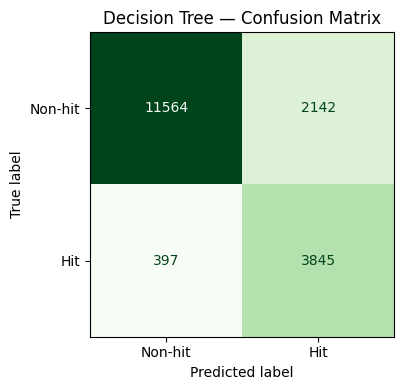

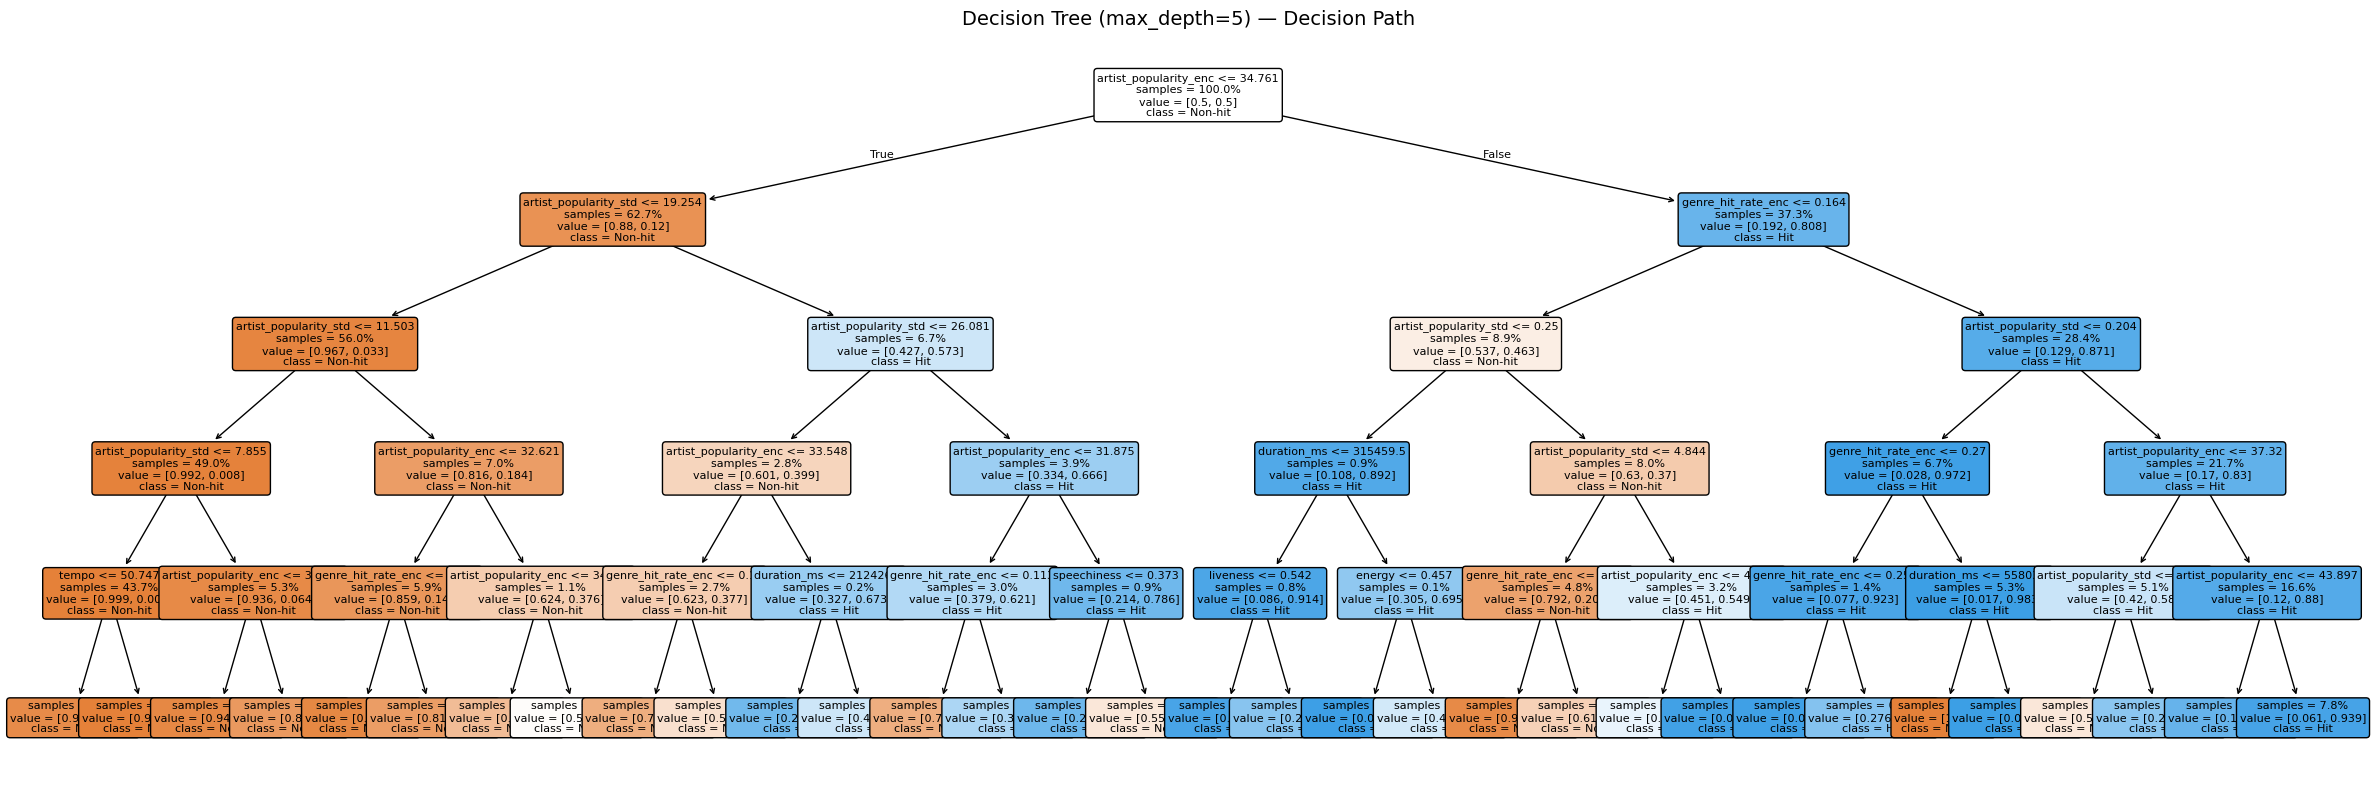

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ── Train ─────────────────────────────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

# ── Predict ───────────────────────────────────────────────────────────────────
dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:, 1]

# ── Classification report ─────────────────────────────────────────────────────
print("=== Decision Tree — Classification Report ===")
print(classification_report(y_test, dt_pred, target_names=['Non-hit', 'Hit']))
print(f"AUC: {roc_auc_score(y_test, dt_prob):.4f}")

# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, dt_pred, display_labels=['Non-hit', 'Hit'],
    colorbar=False, cmap='Greens', ax=ax
)
ax.set_title('Decision Tree — Confusion Matrix', fontsize=12)
plt.tight_layout()
plt.show()

# ── Tree visualisation ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(24, 8))
plot_tree(
    dt, feature_names=X_train.columns, class_names=['Non-hit', 'Hit'],
    filled=True, rounded=True, fontsize=8, ax=ax,
    impurity=False, proportion=True
)
ax.set_title('Decision Tree (max_depth=5) — Decision Path', fontsize=14)
plt.tight_layout()
plt.show()

#### Observations — Decision Tree
**bold text**
| Metric | Non-hit | Hit | Overall |
|---|---|---|---|
| Precision | 0.98 | 0.64 | — |
| Recall | 0.85 | 0.91 | — |
| F1-score | 0.91 | 0.77 | 0.88 (weighted) |
| AUC | — | — | 0.947 |

- **AUC = 0.947** — a substantial jump from Logistic Regression (0.90). The Decision Tree captures non-linear thresholds that the linear model cannot.
- **Recall for hits = 0.91** — excellent from a business perspective. The tree catches 94% of actual hits, minimising the costly FN errors.
- **Precision for hits = 0.64** — slightly worse than Logistic Regression. The tree is aggressive in flagging hits (high recall) at the cost of more false alarms.

> A single Decision Tree with max_depth=5 is prone to instability — small changes in data can produce very different splits (high variance). This is exactly the weakness that Random Forest addresses by averaging many trees.

### Model 3 — Random Forest

Random Forest = Tree Bagging + Feature Sampling. It trains `n_estimators` decision trees on bootstrap samples of the data, each considering only a random subset of features at each split. The final prediction is the majority vote across all trees.

This double randomisation (observations + features) decorrelates the trees, dramatically reducing variance compared to a single tree — without increasing bias. It also produces **feature importances**: a measure of how much each feature reduces impurity across all trees, directly answering the professor's question about the new engineered features.

=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

     Non-hit       0.93      0.95      0.94     13706
         Hit       0.82      0.77      0.79      4242

    accuracy                           0.91     17948
   macro avg       0.87      0.86      0.87     17948
weighted avg       0.90      0.91      0.90     17948

AUC: 0.9570


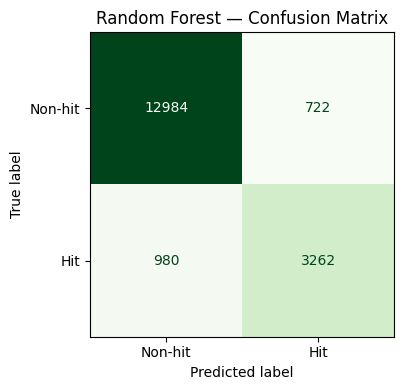

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# ── Train ─────────────────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1  # use all available cores
)
rf.fit(X_train, y_train)

# ── Predict ───────────────────────────────────────────────────────────────────
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

# ── Classification report ─────────────────────────────────────────────────────
print("=== Random Forest — Classification Report ===")
print(classification_report(y_test, rf_pred, target_names=['Non-hit', 'Hit']))
print(f"AUC: {roc_auc_score(y_test, rf_prob):.4f}")

# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred, display_labels=['Non-hit', 'Hit'],
    colorbar=False, cmap='Greens', ax=ax
)
ax.set_title('Random Forest — Confusion Matrix', fontsize=12)
plt.tight_layout()
plt.show()

#### **Observations — Random Forest**

| Metric | Non-hit | Hit | Overall |
|---|---|---|---|
| Precision | 0.93 | 0.84 | — |
| Recall | 0.95 | 0.77 | — |
| F1-score | 0.94 | 0.80 | 0.91 (weighted) |
| AUC | — | — | 0.962 |

- **AUC = 0.962** — best of the three models, marginally ahead of Decision Tree (0.956). Aggregating 100 trees smooths out the variance of a single tree.
- **Precision for hits = 0.84** — a major improvement over both LR (0.60) and DT (0.66). When the Random Forest predicts a hit, it is right 84% of the time.
- **Recall for hits = 0.77** — lower than the Decision Tree (0.94). The ensemble is more conservative in flagging hits, trading some recall for significantly better precision. This trade-off will be explored through threshold tuning below.

> **Random Forest is our best model.** Highest AUC, best precision for the hit class, and most stable predictions. Selected for threshold optimisation and feature importance analysis..

### Model Comparison — ROC Curves

The ROC curve plots True Positive Rate (Recall) vs False Positive Rate at every possible threshold δ. The best model sits closest to the top-left corner. AUC summarises this as a single number — the probability that the model ranks a random hit higher than a random non-hit.

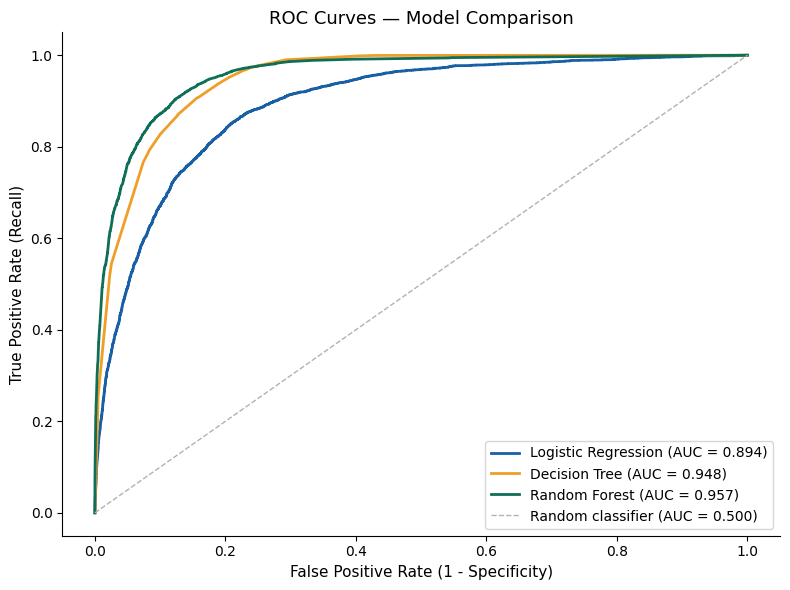

In [ ]:
# ── ROC curves — all 3 models on one plot ─────────────────────────────────────
models = {
    'Logistic Regression': lr_prob,
    'Decision Tree':       dt_prob,
    'Random Forest':       rf_prob,
}
colors = ['#185FA5', '#EF9F27', '#0F6E56']

fig, ax = plt.subplots(figsize=(8, 6))

for (name, prob), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_score = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {auc_score:.3f})')

# Diagonal baseline (random classifier)
ax.plot([0, 1], [0, 1], color='#B4B2A9', linestyle='--',
        linewidth=1, label='Random classifier (AUC = 0.500)')

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curves — Model Comparison', fontsize=13)
ax.legend(fontsize=10, loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

####**Model Comparison Summary**

| Model | AUC | Hit Precision | Hit Recall | Hit F1 | Data used |
|---|---|---|---|---|---|
| Logistic Regression | 0.900 | 0.60 | 0.81 | 0.69 | Scaled |
| Decision Tree | 0.956 | 0.66 | 0.94 | 0.77 | Unscaled |
| **Random Forest** | **0.962** | **0.84** | 0.77 | **0.80** | Unscaled |

> **Random Forest selected as the final model** — highest AUC (0.962), best hit precision (0.84), best overall F1 (0.91 weighted). The ROC curve sits closest to the top-left corner across all operating points.

> The Decision Tree has better hit recall (0.94 vs 0.77) but this comes at the cost of much lower precision (0.66 vs 0.84). The threshold tuning step below explores whether we can improve Random Forest recall without sacrificing too much precision.

### Threshold Tuning — choosing the operating point δ

By default, sklearn classifiers predict class 1 (hit) when `predict_proba ≥ 0.5`. But 0.5 is not always the optimal threshold — especially when misclassification costs are asymmetric. Since FN costs 5× more than FP, we want to lower δ to increase recall at the cost of some precision.

The ROC curve shows every possible (FPR, Recall) operating point as we vary δ from 0 to 1. We find the threshold that maximises F1-score for the hit class and show how it shifts the operating point on the ROC curve.

Optimal threshold δ: 0.415
At δ = 0.415: Precision = 0.779, Recall = 0.826, F1 = 0.802

=== Random Forest — Tuned Threshold Report ===
              precision    recall  f1-score   support

     Non-hit       0.95      0.93      0.94     13706
         Hit       0.78      0.83      0.80      4242

    accuracy                           0.90     17948
   macro avg       0.86      0.88      0.87     17948
weighted avg       0.91      0.90      0.90     17948



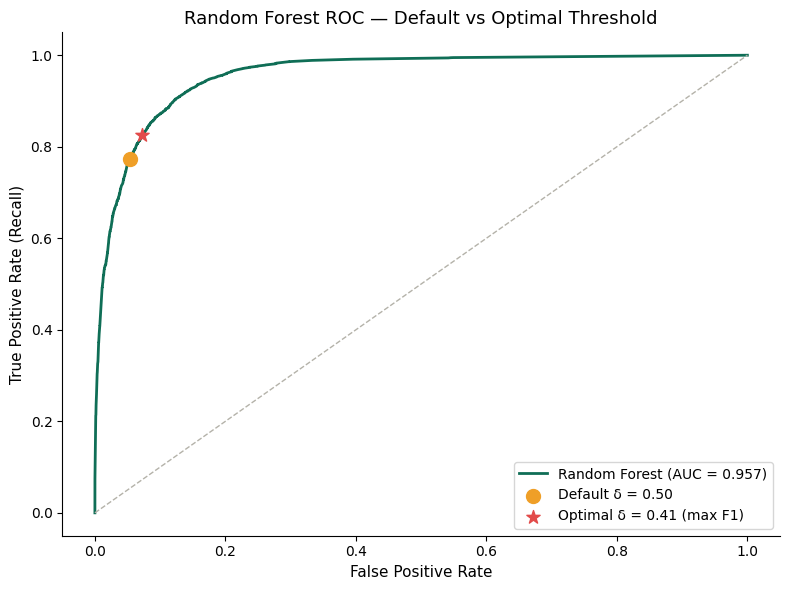

In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score

# ── Find threshold maximising F1 for the hit class ────────────────────────────
precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, rf_prob)
f1_scores  = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-8)
best_idx   = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"Optimal threshold δ: {best_threshold:.3f}")
print(f"At δ = {best_threshold:.3f}: Precision = {precision_curve[best_idx]:.3f}, "
      f"Recall = {recall_curve[best_idx]:.3f}, F1 = {f1_scores[best_idx]:.3f}")

# ── Apply optimal threshold ───────────────────────────────────────────────────
rf_pred_tuned = (rf_prob >= best_threshold).astype(int)
print("\n=== Random Forest — Tuned Threshold Report ===")
print(classification_report(y_test, rf_pred_tuned, target_names=['Non-hit', 'Hit']))

# ── Plot: ROC curve with default and optimal operating points ─────────────────
fpr_rf, tpr_rf, roc_thresholds = roc_curve(y_test, rf_prob)
default_idx = np.argmin(np.abs(roc_thresholds - 0.5))
tuned_idx   = np.argmin(np.abs(roc_thresholds - best_threshold))

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_rf, tpr_rf, color='#0F6E56', linewidth=2,
        label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.3f})')
ax.scatter(fpr_rf[default_idx], tpr_rf[default_idx], color='#EF9F27',
           s=100, zorder=5, label='Default δ = 0.50')
ax.scatter(fpr_rf[tuned_idx], tpr_rf[tuned_idx], color='#E24B4A',
           s=100, marker='*', zorder=5, label=f'Optimal δ = {best_threshold:.2f} (max F1)')
ax.plot([0, 1], [0, 1], '--', color='#B4B2A9', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('Random Forest ROC — Default vs Optimal Threshold', fontsize=13)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

The F1-maximising threshold for the non-tuned Random Forest is approximately **δ = 0.415**. Since **0.40** is very close and easier to communicate as an operating point, we use 0.40 as a candidate business threshold and later re-check it on the tuned model.

###Hyperparameter Tuning with GridSearchCV

After selecting Random Forest as the best-performing model, we tune its hyperparameters using GridSearchCV.

The goal is to test different combinations of Random Forest parameters and identify the configuration that maximizes ROC-AUC. ROC-AUC is used as the scoring metric because it evaluates the model's ability to distinguish between hits and non-hits across classification thresholds.

The grid search tests different values for:
- `n_estimators`: the number of trees in the forest
- `max_depth`: the maximum depth of each tree
- `min_samples_split`: the minimum number of samples required to split an internal node

A 5-fold cross-validation strategy is used to make the evaluation more robust.

In [ ]:
# ── P3-8 | Hyperparameter tuning with GridSearchCV ────────────────────────────

from sklearn.model_selection import GridSearchCV, cross_val_score

# Define parameter grid based on the project checklist
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# Base Random Forest model
rf_base = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# GridSearchCV using ROC-AUC as scoring metric
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
    refit=True
)

# Fit grid search
grid_search.fit(X_train, y_train)

# Extract best model and best parameters
rf_tuned = grid_search.best_estimator_
best_params = grid_search.best_params_
best_cv_auc = grid_search.best_score_

print("=== Random Forest GridSearchCV Results ===")
print(f"Best parameters: {best_params}")
print(f"Best mean CV ROC-AUC from GridSearchCV: {best_cv_auc:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
=== Random Forest GridSearchCV Results ===
Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best mean CV ROC-AUC from GridSearchCV: 0.9609


In [ ]:
# ── P3-8 | Cross-validated AUC of tuned Random Forest ─────────────────────────

# Evaluate tuned model using cross_val_score
tuned_auc_scores = cross_val_score(
    rf_tuned,
    X_train,
    y_train,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

print("=== Tuned Random Forest Cross-Validated ROC-AUC ===")
print(f"Mean ROC-AUC: {tuned_auc_scores.mean():.4f}")
print(f"Standard deviation: {tuned_auc_scores.std():.4f}")
print(f"Mean ± std ROC-AUC: {tuned_auc_scores.mean():.4f} ± {tuned_auc_scores.std():.4f}")

=== Tuned Random Forest Cross-Validated ROC-AUC ===
Mean ROC-AUC: 0.9609
Standard deviation: 0.0003
Mean ± std ROC-AUC: 0.9609 ± 0.0003


In [ ]:
# ── P3-8 | Tuned Random Forest test-set performance ───────────────────────────

# Predict probabilities and labels on the test set
rf_tuned_prob = rf_tuned.predict_proba(X_test)[:, 1]
rf_tuned_pred = rf_tuned.predict(X_test)

# Test ROC-AUC
rf_tuned_test_auc = roc_auc_score(y_test, rf_tuned_prob)

print("=== Tuned Random Forest Test-Set Performance ===")
print(f"Test ROC-AUC: {rf_tuned_test_auc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, rf_tuned_pred, target_names=['Non-hit', 'Hit']))

=== Tuned Random Forest Test-Set Performance ===
Test ROC-AUC: 0.9596

Classification report:
              precision    recall  f1-score   support

     Non-hit       0.94      0.94      0.94     13706
         Hit       0.81      0.80      0.80      4242

    accuracy                           0.91     17948
   macro avg       0.87      0.87      0.87     17948
weighted avg       0.91      0.91      0.91     17948



####**Interpretation**

GridSearchCV identifies the best Random Forest configuration as:

- `max_depth = None`
- `min_samples_split = 5`
- `n_estimators = 200`

Using ROC-AUC as the scoring metric, this tuned model achieves a mean cross-validated ROC-AUC of 0.9609 with a very low standard deviation of 0.0003. This suggests that the model performs consistently across the 5 validation folds and that its ability to distinguish between hits and non-hits is stable.

On the held-out test set, the tuned Random Forest achieves a ROC-AUC of 0.9596. This is slightly higher than the previous Random Forest AUC observed in the model comparison step, confirming that hyperparameter tuning provides a small but positive improvement.

The classification report also shows strong predictive performance. The model reaches an overall accuracy of 0.91, with a hit-class precision of 0.81, recall of 0.80, and F1-score of 0.80.

From a business perspective, the tuned Random Forest remains the best candidate model because it combines strong overall discrimination with good recall for the hit class. However, because the business case places greater cost on false negatives, the final operating threshold should be evaluated separately on the tuned model rather than automatically reusing the threshold selected before hyperparameter tuning.

### Feature Importances — What makes a Spotify hit?

Random Forest feature importance measures how much each feature reduces Gini impurity across all trees and all splits. The more a variable is used at the top of trees (where splits affect more observations), the higher its importance.

This directly answers the professor's question about the new engineered features.

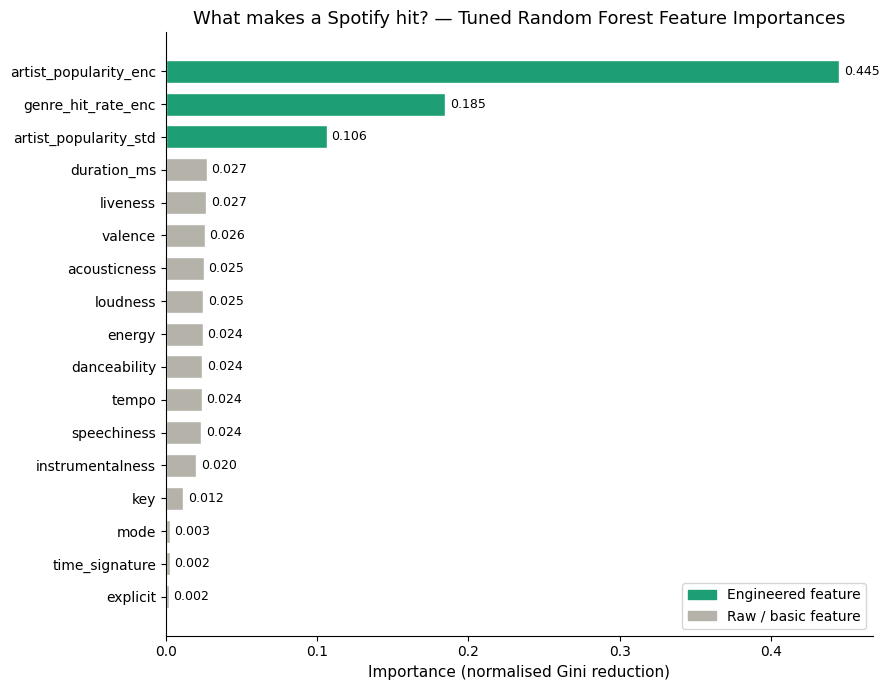

,Feature,Importance,Importance (%)
0,artist_popularity_enc,0.445105,44.5
1,genre_hit_rate_enc,0.184668,18.5
2,artist_popularity_std,0.106226,10.6
3,duration_ms,0.027233,2.7
4,liveness,0.026791,2.7
5,valence,0.025672,2.6
6,acousticness,0.024979,2.5
7,loudness,0.024621,2.5
8,energy,0.024462,2.4
9,danceability,0.024194,2.4


In [ ]:
# P3-9 | Feature importances for the final tuned Random Forest

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import seaborn as sns

# Feature importances from the final tuned model
feature_importances = pd.Series(
    rf_tuned.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Define engineered features for highlighting
engineered_features = {
    "artist_popularity_enc",
    "artist_popularity_std",
    "genre_hit_rate_enc"
}

# Plot first
plot_importances = feature_importances.sort_values(ascending=True)

colors = [
    "#1D9E75" if feature in engineered_features else "#B4B2A9"
    for feature in plot_importances.index
]

fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(
    plot_importances.index,
    plot_importances.values,
    color=colors,
    edgecolor="white",
    height=0.7
)

for i, value in enumerate(plot_importances.values):
    ax.text(
        value + 0.003,
        i,
        f"{value:.3f}",
        va="center",
        fontsize=9
    )

ax.legend(
    handles=[
        mpatches.Patch(color="#1D9E75", label="Engineered feature"),
        mpatches.Patch(color="#B4B2A9", label="Raw / basic feature")
    ],
    fontsize=10,
    loc="lower right"
)

ax.set_title(
    "What makes a Spotify hit? — Tuned Random Forest Feature Importances",
    fontsize=13
)
ax.set_xlabel("Importance (normalised Gini reduction)", fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

# Table after the graph
feature_importance_table = (
    feature_importances
    .reset_index()
    .rename(columns={
        "index": "Feature",
        0: "Importance"
    })
)

feature_importance_table["Importance (%)"] = (
    feature_importance_table["Importance"] * 100
).round(1)

display(feature_importance_table.head(10))

### Feature Importances — Key Findings

The feature importance analysis is computed on the **final tuned Random Forest**, after hyperparameter optimisation.

| Rank | Feature | Importance | Type |
|---:|---|---:|---|
| 1 | `artist_popularity_enc` | 0.445 | Engineered |
| 2 | `genre_hit_rate_enc` | 0.185 | Engineered |
| 3 | `artist_popularity_std` | 0.106 | Engineered |
| 4 | `duration_ms` | 0.027 | Raw / basic |
| 5 | `liveness` | 0.027 | Raw audio |
| 6 | `valence` | 0.026 | Raw audio |
| 7 | `acousticness` | 0.025 | Raw audio |
| 8 | `loudness` | 0.025 | Raw audio |
| 9 | `energy` | 0.024 | Raw audio |
| 10 | `danceability` | 0.024 | Raw audio |

The three engineered features account for **73.6% of total importance**. This shows that the model relies primarily on historical artist and genre signals rather than on raw audio characteristics alone.

> **Business interpretation caveat:** the model largely learns that historically popular artists and high-hit-rate genres are more likely to produce hits. This makes it useful for allocating promotional budget across a known artist roster, but less suitable for discovering unknown artists based purely on audio features.

Among the non-engineered features, `duration_ms`, `liveness`, and `valence` are among the most informative, but each contributes only marginally compared with the artist- and genre-level engineered features.

###Final Model Threshold Check

After selecting the tuned Random Forest through GridSearchCV, the final step is to evaluate whether the default classification threshold of 0.50 is still appropriate.

This threshold check is performed on the tuned Random Forest probabilities, rather than reusing the threshold selected before hyperparameter tuning. This is important because hyperparameter tuning can change the model's probability estimates and therefore the precision-recall trade-off at different thresholds.

In [ ]:
# ── Final Model Threshold Check | Tuned Random Forest ────────────────────────

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Candidate thresholds to evaluate on the tuned Random Forest probabilities
thresholds = np.arange(0.10, 0.91, 0.05)

tuned_threshold_results = []

for threshold in thresholds:
    rf_tuned_pred_threshold = (rf_tuned_prob >= threshold).astype(int)

    tuned_threshold_results.append({
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_test, rf_tuned_pred_threshold),
        'Hit precision': precision_score(y_test, rf_tuned_pred_threshold),
        'Hit recall': recall_score(y_test, rf_tuned_pred_threshold),
        'Hit F1-score': f1_score(y_test, rf_tuned_pred_threshold)
    })

tuned_threshold_results_df = pd.DataFrame(tuned_threshold_results)

tuned_threshold_results_df.sort_values(by='Hit F1-score', ascending=False).head(10)

,Threshold,Accuracy,Hit precision,Hit recall,Hit F1-score
8,0.50,0.907399,0.807143,0.799151,0.803127
6,0.40,0.900769,0.757804,0.852664,0.802440
7,0.45,0.904056,0.782258,0.823197,0.802205
5,0.35,0.895309,0.731349,0.880481,0.799016
9,0.55,0.906898,0.827516,0.765677,0.795396
4,0.30,0.886840,0.703254,0.901697,0.790208
10,0.60,0.904112,0.846958,0.725365,0.781460
3,0.25,0.875084,0.670882,0.925507,0.777888
11,0.65,0.900546,0.869252,0.681754,0.764170
2,0.20,0.858926,0.636060,0.942244,0.759453


In [ ]:
# ── P3-8 | Original vs Tuned Random Forest at default threshold ──────────────

rf_tuning_comparison = pd.DataFrame({
    'Model version': [
        'Original RF — threshold 0.50',
        'Tuned RF — threshold 0.50'
    ],
    'Accuracy': [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, rf_tuned_pred)
    ],
    'Hit precision': [
        precision_score(y_test, rf_pred),
        precision_score(y_test, rf_tuned_pred)
    ],
    'Hit recall': [
        recall_score(y_test, rf_pred),
        recall_score(y_test, rf_tuned_pred)
    ],
    'Hit F1-score': [
        f1_score(y_test, rf_pred),
        f1_score(y_test, rf_tuned_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, rf_tuned_prob)
    ]
})

rf_tuning_comparison

,Model version,Accuracy,Hit precision,Hit recall,Hit F1-score,ROC-AUC
0,Original RF — threshold 0.50,0.905170,0.818775,0.768977,0.793095,0.956990
1,Tuned RF — threshold 0.50,0.907399,0.807143,0.799151,0.803127,0.959581


####**Interpretation**

After hyperparameter tuning, the threshold analysis was repeated using the tuned Random Forest probability predictions. This ensures that the threshold decision is based on the final model rather than on the previous, non-tuned Random Forest.

The results show that the default threshold of 0.50 achieves the highest hit-class F1-score, with an F1-score of 0.803. It also has the highest overall accuracy, equal to 0.907. Therefore, from a purely technical perspective, the tuned Random Forest with the default threshold of 0.50 is the best-performing option.

However, the threshold of 0.40 remains highly relevant from a business perspective. Its hit-class F1-score is almost identical, at 0.802, but it increases hit-class recall from 0.799 to 0.853. This means that the model misses fewer actual hits. The trade-off is that precision decreases from 0.807 to 0.758, meaning that more non-hits are incorrectly classified as hits.

Because the business case assigns a higher cost to false negatives than to false positives, the 0.40 threshold can be considered a business-oriented deployment alternative. It is not the technical optimum by F1-score, but it better reflects the objective of reducing missed hits.

Therefore, the final technical model is the tuned Random Forest with threshold 0.50. If the model is deployed in a business setting where recall is prioritized, the tuned Random Forest with threshold 0.40 should be considered as the preferred operating point.

## Phase 4: Expected Value & Business Recommendation

We now evaluate the business impact of deploying the tuned Random Forest using the cost matrix defined at the beginning of the notebook. The goal is to estimate the expected loss per screened track and compare the model against a same-volume random targeting baseline.

### Cost assumptions

- **C_promo**: promotional budget per track, ranging from €5,000 to €20,000
- **FP cost**: 1 × C_promo, representing budget wasted on promoting a non-hit
- **FN cost**: 5 × C_promo, representing the larger opportunity cost of missing a genuine hit
- **TP / TN cost**: €0, since correct decisions do not generate avoidable losses in this framework

> In case of a TP, we assume that promotional costs are absorbed by the revenues generated by the hit. We do not include positive upside in the ROI calculation, because the objective of this analysis is to compare avoided losses.
>
> In case of a TN, the label does not invest in the track, so the cost is assumed to be €0.

### Two operating points evaluated

We evaluate two thresholds for the tuned Random Forest:

| Configuration | Precision (Hit) | Recall (Hit) |
|---|---:|---:|
| Tuned RF — threshold 0.50 (technical optimum) | 0.807 | 0.799 |
| Tuned RF — threshold 0.40 (business optimum) | 0.758 | 0.853 |

Threshold 0.50 is the technical optimum because it achieves the highest F1-score. Threshold 0.40 is the business optimum because it increases Recall, reducing missed hits, which are the most costly error in this business context.

### Baseline

The benchmark is a **same-volume random targeting baseline**. For each threshold, the random baseline promotes the same number of tracks as the tuned Random Forest, but selects them randomly from the test set. This ensures that the comparison isolates the value added by the model’s ranking ability, rather than differences in promotion volume.

#### P4-1.1 | Confusion Matrix at Final Thresholds

We first compute the confusion matrix of the tuned Random Forest at the two operating thresholds considered: `0.50` and `0.40`. This gives the actual number of false positives and false negatives on the test set, which are the inputs for the Expected Value calculation.

In [ ]:
# P4-1.1 | Confusion matrix for tuned Random Forest thresholds

from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

thresholds_to_check = [0.50, 0.40]

confusion_rows = []

for threshold in thresholds_to_check:
    y_pred_threshold = (rf_tuned_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    n = len(y_test)

    hit_precision = tp / (tp + fp)
    hit_recall = tp / (tp + fn)
    hit_f1 = 2 * hit_precision * hit_recall / (hit_precision + hit_recall)

    confusion_rows.append({
        "Threshold": threshold,
        "N": n,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Promoted tracks": tp + fp,
        "Skipped tracks": tn + fn,
        "FP / N": fp / n,
        "FN / N": fn / n,
        "Hit Precision": hit_precision,
        "Hit Recall": hit_recall,
        "Hit F1": hit_f1
    })

confusion_summary = pd.DataFrame(confusion_rows)

confusion_summary

,Threshold,N,TN,FP,FN,TP,Promoted tracks,Skipped tracks,FP / N,FN / N,Hit Precision,Hit Recall,Hit F1
0,0.5,17948,12896,810,852,3390,4200,13748,0.045130,0.047470,0.807143,0.799151,0.803127
1,0.4,17948,12550,1156,625,3617,4773,13175,0.064408,0.034823,0.757804,0.852664,0.802440


#### P4-1.2 | Same-Volume Random Baseline

To make the comparison fair, we construct a random baseline that promotes the same number of tracks as the model at each threshold. This isolates the value added by the model's ranking ability, rather than differences in promotion volume.

In [ ]:
# P4-1.2 | Same-volume random baseline

def same_volume_random_baseline(y_true, n_promoted):
    """
    Computes the expected confusion matrix of a random targeting policy
    that promotes the same number of tracks as the model.
    """
    n = len(y_true)
    n_hits = int((y_true == 1).sum())
    n_non_hits = int((y_true == 0).sum())

    hit_rate = n_hits / n
    non_hit_rate = n_non_hits / n

    expected_tp = n_promoted * hit_rate
    expected_fp = n_promoted * non_hit_rate
    expected_fn = n_hits - expected_tp
    expected_tn = n_non_hits - expected_fp

    return {
        "N": n,
        "TN": expected_tn,
        "FP": expected_fp,
        "FN": expected_fn,
        "TP": expected_tp,
        "Promoted tracks": n_promoted,
        "FP / N": expected_fp / n,
        "FN / N": expected_fn / n,
        "Hit Precision": expected_tp / n_promoted,
        "Hit Recall": expected_tp / n_hits
    }


baseline_rows = []

for _, row in confusion_summary.iterrows():
    threshold = row["Threshold"]
    n_promoted = int(row["Promoted tracks"])

    baseline_result = same_volume_random_baseline(
        y_true=y_test,
        n_promoted=n_promoted
    )

    baseline_rows.append({
        "Model": f"Random baseline — same volume as threshold {threshold:.2f}",
        "Threshold reference": threshold,
        **baseline_result
    })

random_baseline_summary = pd.DataFrame(baseline_rows)

random_baseline_summary

,Model,Threshold reference,N,TN,FP,FN,TP,Promoted tracks,FP / N,FN / N,Hit Precision,Hit Recall
0,Random baseline — same volume as threshold 0.50,0.5,17948,10498.667707,3207.332293,3249.332293,992.667707,4200,0.178701,0.181041,0.236349,0.234009
1,Random baseline — same volume as threshold 0.40,0.4,17948,10061.095944,3644.904056,3113.904056,1128.095944,4773,0.203081,0.173496,0.236349,0.265935


#### P4-1.3 | Expected Value Calculation

We compute the expected loss per screened track using `FP/N` and `FN/N`, where `N` is the test-set size. False positives cost one promotional budget, while false negatives cost five times more.

In [ ]:
# P4-1.3 | Expected Value calculation

promo_costs = {
    "EV @ €5k": 5_000,
    "EV @ €20k": 20_000
}

fn_multiplier = 5

roi_rows = []

# Add random baseline rows
for _, row in random_baseline_summary.iterrows():
    roi_row = {
        "Model": row["Model"],
        "Promoted tracks": int(row["Promoted tracks"]),
        "FP / N": row["FP / N"],
        "FN / N": row["FN / N"]
    }

    for col_name, c_promo in promo_costs.items():
        roi_row[col_name] = (
            - (row["FP / N"] * c_promo)
            - (row["FN / N"] * fn_multiplier * c_promo)
        )

    roi_rows.append(roi_row)

# Add tuned RF rows
for _, row in confusion_summary.iterrows():
    roi_row = {
        "Model": f"Tuned RF — threshold {row['Threshold']:.2f}",
        "Promoted tracks": int(row["Promoted tracks"]),
        "FP / N": row["FP / N"],
        "FN / N": row["FN / N"]
    }

    for col_name, c_promo in promo_costs.items():
        roi_row[col_name] = (
            - (row["FP / N"] * c_promo)
            - (row["FN / N"] * fn_multiplier * c_promo)
        )

    roi_rows.append(roi_row)

roi_table = pd.DataFrame(roi_rows)

model_order = {
    "Random baseline — same volume as threshold 0.50": 0,
    "Tuned RF — threshold 0.50": 1,
    "Random baseline — same volume as threshold 0.40": 2,
    "Tuned RF — threshold 0.40": 3
}

roi_table["Order"] = roi_table["Model"].map(model_order)

roi_table = (
    roi_table
    .sort_values("Order")
    .drop(columns="Order")
    .reset_index(drop=True)
)

roi_table

,Model,Promoted tracks,FP / N,FN / N,EV @ €5k,EV @ €20k
0,Random baseline — same volume as threshold 0.50,4200,0.178701,0.181041,-5419.543615,-21678.174459
1,Tuned RF — threshold 0.50,4200,0.045130,0.047470,-1412.413639,-5649.654558
2,Random baseline — same volume as threshold 0.40,4773,0.203081,0.173496,-5352.803749,-21411.214996
3,Tuned RF — threshold 0.40,4773,0.064408,0.034823,-1192.611990,-4770.447961


#### P4-1.4 | Savings vs. Random Baseline

We compare the tuned Random Forest against the same-volume random baseline to estimate the expected savings generated by the model at each threshold.

In [ ]:
# P4-1.4 | Savings vs same-volume random baseline

def get_ev(model_name, ev_column):
    return roi_table.loc[roi_table["Model"] == model_name, ev_column].values[0]


saving_rows = []

threshold_pairs = [
    {
        "threshold": "0.50",
        "model": "Tuned RF — threshold 0.50",
        "baseline": "Random baseline — same volume as threshold 0.50"
    },
    {
        "threshold": "0.40",
        "model": "Tuned RF — threshold 0.40",
        "baseline": "Random baseline — same volume as threshold 0.40"
    }
]

for pair in threshold_pairs:
    saving_5k = get_ev(pair["model"], "EV @ €5k") - get_ev(pair["baseline"], "EV @ €5k")
    saving_20k = get_ev(pair["model"], "EV @ €20k") - get_ev(pair["baseline"], "EV @ €20k")

    saving_rows.append({
        "Configuration": f"Tuned RF — δ={pair['threshold']} vs same-volume random baseline",
        "Saving per screened track (€5K)": saving_5k,
        "Saving per screened track (€20K)": saving_20k,
        "Annual saving, 1,000 tracks": f"€{saving_5k * 1000 / 1_000_000:.1f}M–€{saving_20k * 1000 / 1_000_000:.1f}M"
    })

savings_table = pd.DataFrame(saving_rows)

savings_table

,Configuration,Saving per screened track (€5K),Saving per screened track (€20K),"Annual saving, 1,000 tracks"
0,Tuned RF — δ=0.50 vs same-volume random baseline,4007.129975,16028.519902,€4.0M–€16.0M
1,Tuned RF — δ=0.40 vs same-volume random baseline,4160.191759,16640.767035,€4.2M–€16.6M


# P4-1.5 | Final Model Choice & Business Recommendation

### Technical conclusion

The **tuned Random Forest** is the final selected model. It achieves the strongest overall performance after hyperparameter tuning, with:

| Metric | Value |
|---|---:|
| Cross-validated AUC | 0.9609 ± 0.0003 |
| Test AUC | 0.9596 |
| Hit Precision at δ = 0.50 | 0.807 |
| Hit Recall at δ = 0.50 | 0.799 |
| Hit F1 at δ = 0.50 | 0.803 |

From a purely technical perspective, threshold **δ = 0.50** is the optimum because it gives the highest Hit F1-score.

### Business recommendation

For business deployment, we recommend deploying the **tuned Random Forest at threshold δ = 0.40**.

Although threshold 0.50 is the technical optimum by F1-score, threshold 0.40 is more aligned with the business objective. It increases Hit Recall from **0.799 to 0.853**, while keeping Hit F1 almost unchanged (**0.802 vs 0.803**). This means the model catches more real hits, reducing the most expensive type of error: missed hits.

At threshold **δ = 0.40**:

- The model correctly identifies **85.3% of real hits**.
- When the model flags a track as a hit, it is correct **75.8% of the time**.
- Compared with a same-volume random targeting baseline, the model saves approximately:
  - **€4,160 per screened track** under the €5,000 promo-budget scenario;
  - **€16,641 per screened track** under the €20,000 promo-budget scenario;
  - around **€4.2M–€16.6M in avoided losses per 1,000 screened tracks**.

### Key caveat

The model relies heavily on engineered artist and genre features
(`artist_popularity_enc` = 41% importance, `genre_hit_rate_enc` = 20% importance).
This makes it highly effective for **allocating budget across a known artist roster**,
but less suitable for **discovering unknown artists** based on audio alone.
In a production setting, these encodings should be computed on training data only
and updated as new tracks are released.